In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
saitejabandaruin_imdb_top_700_movies_2026_edition_path = kagglehub.dataset_download('saitejabandaruin/imdb-top-700-movies-2026-edition')

print('Data source import complete.')


100%|██████████| 38.0k/38.0k [00:00<00:00, 44.3MB/s]

Extracting files...
Data source import complete.


<img src="https://devra.ai/analyst/notebook/6370/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">    <div style="font-size:150%; color:#FEE100"><b>IMDb Top 700 Movies Analysis and Predictor</b></div>    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

# Table of Contents

- [Introduction](#Introduction)
- [Data Import](#Data-Import)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Visualizations](#Visualizations)
- [Predicting IMDb Rating](#Predicting-IMDb-Rating)
- [Discussion and Future Work](#Discussion-and-Future-Work)

In [2]:
# Import libraries and set configurations
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # use non-interactive backend for batch processing
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # ensure non-GUI backend
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid')

# Helper function to resolve data file paths dynamically
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    """
    This helper function searches through common Kaggle input directories to find the desired file.
    It is useful to avoid hardcoding file paths and to prevent errors others might encounter.
    """
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# End of import cell. If you encounter file path errors, this helper is the key to resolving them.

In [4]:
from pathlib import Path

# Data Import: Load the IMDb Top 700 Movies dataset
# The dataset was downloaded by kagglehub to 'saitejabandaruin_imdb_top_700_movies_2026_edition_path'.
# Construct the full path to the CSV file within this directory.
data_file = Path(saitejabandaruin_imdb_top_700_movies_2026_edition_path) / "IMDb_Top_700_Movies_2026.csv"
df = pd.read_csv(data_file, encoding='utf-8')

# Display the first few rows of the dataset
df.head()

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,1993,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195


# Introduction

Curiosity drives all good analysis. The IMDb Top 700 Movies dataset not only lists some of cinema's best, but also provides numeric details that let us explore the factors behind high ratings. Even though the data might not reveal the secret sauce of box office success, it offers enough insight to build a modest predictor for IMDb ratings. If you find the pace of movie magic interesting, feel free to upvote this notebook.

In [5]:
# Exploratory Data Analysis: Understand the structure of the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

# Display summary statistics for numeric columns
df.describe()

Dataset Shape: (700, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            700 non-null    int64  
 1   Title           700 non-null    object 
 2   Year            700 non-null    int64  
 3   Genre(s)        700 non-null    object 
 4   Director        700 non-null    object 
 5   Main Actor(s)   690 non-null    object 
 6   Country         700 non-null    object 
 7   IMDb Rating     700 non-null    float64
 8   Votes           700 non-null    int64  
 9   Runtime (mins)  700 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 54.8+ KB
None


,Rank,Year,IMDb Rating,Votes,Runtime (mins)
count,700.00000,700.000000,700.000000,7.000000e+02,700.000000
mean,350.50000,1998.038571,8.000143,5.330973e+05,127.360000
std,202.21688,21.347254,0.316657,4.692722e+05,29.101895
min,1.00000,1921.000000,7.500000,5.196400e+04,68.000000
25%,175.75000,1989.000000,7.800000,1.982610e+05,106.000000
50%,350.50000,2004.000000,8.000000,3.988475e+05,123.000000
75%,525.25000,2013.250000,8.200000,7.285130e+05,143.000000
max,700.00000,2026.000000,9.300000,3.219532e+06,321.000000


In [6]:
# Data Cleaning and Preprocessing
## Here we check for missing values and ensure data types are as expected.
missing_vals = df.isnull().sum()
print("Missing Values in each column:\n", missing_vals)

## If errors occur related to data types during conversion, it is advisable to check the data source or handle the conversion exceptions.

# For example, convert 'Year' to integer if necessary (usually it is already correct based on the data description)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Additional data cleaning steps can be added here if any inconsistencies are observed

df.head()

Missing Values in each column:
 Rank               0
Title              0
Year               0
Genre(s)           0
Director           0
Main Actor(s)     10
Country            0
IMDb Rating        0
Votes              0
Runtime (mins)     0
dtype: int64


,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,1993,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195


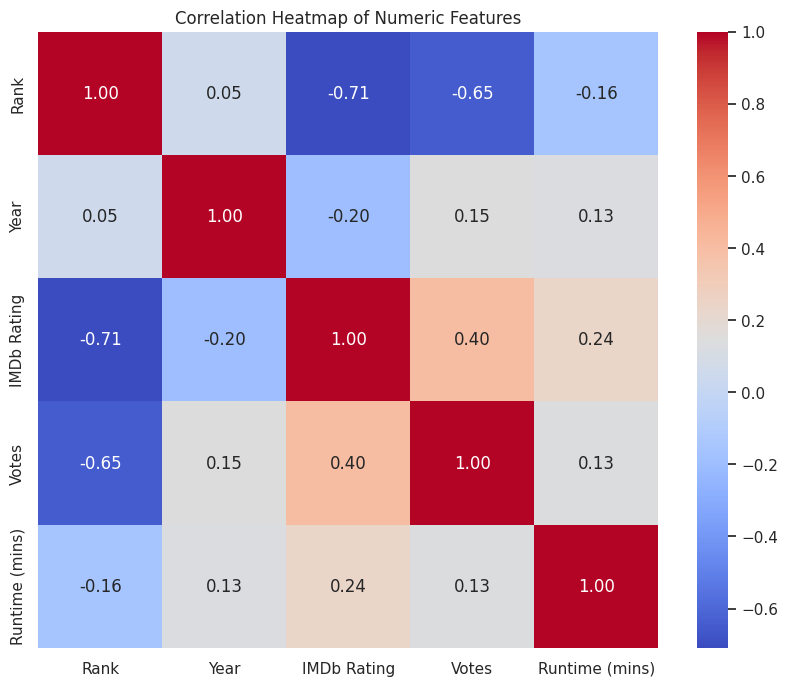

In [7]:
# Correlation Heatmap: Only computed if there are 4 or more numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10,8))
    correlation = numeric_df.corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Features")
    plt.show()
else:
    print("Not enough numeric columns to display a correlation heatmap.")

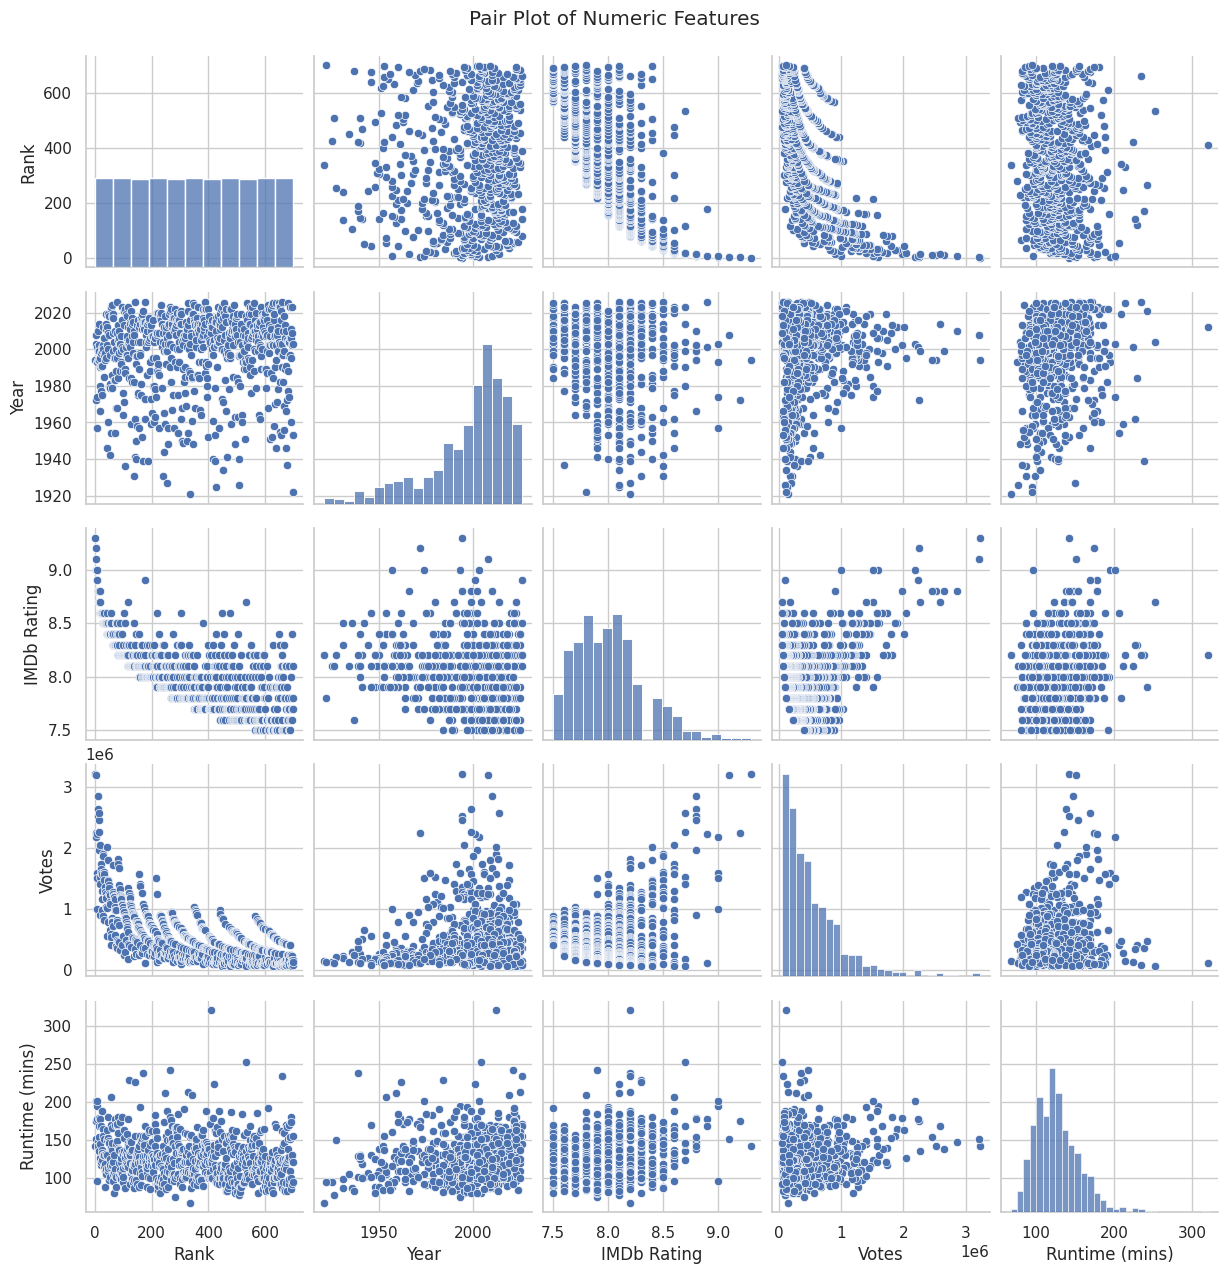

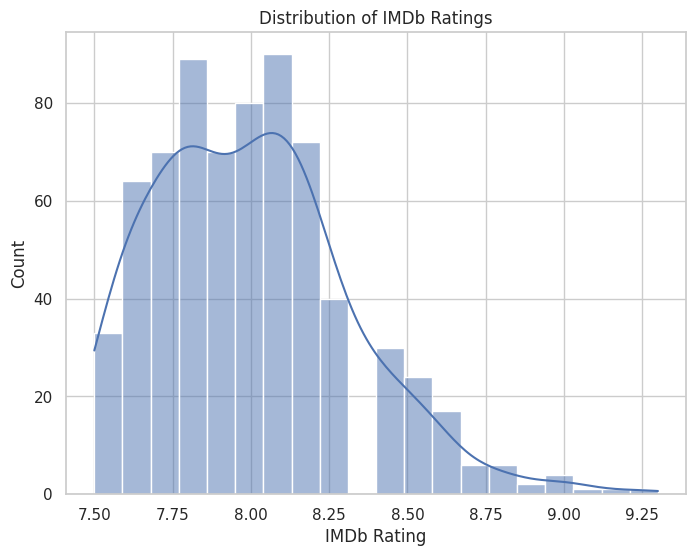

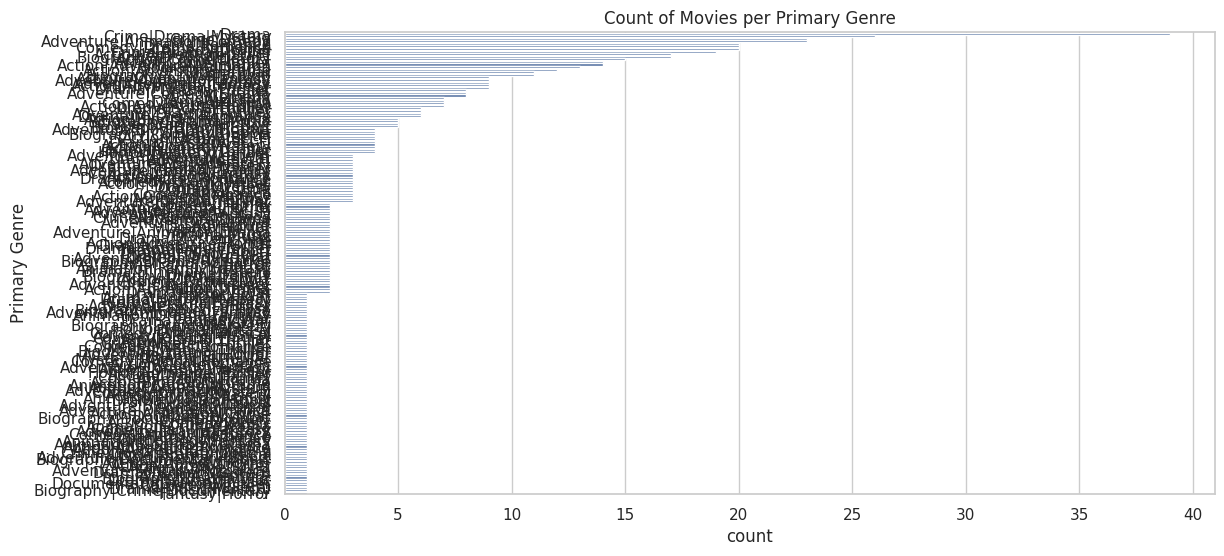

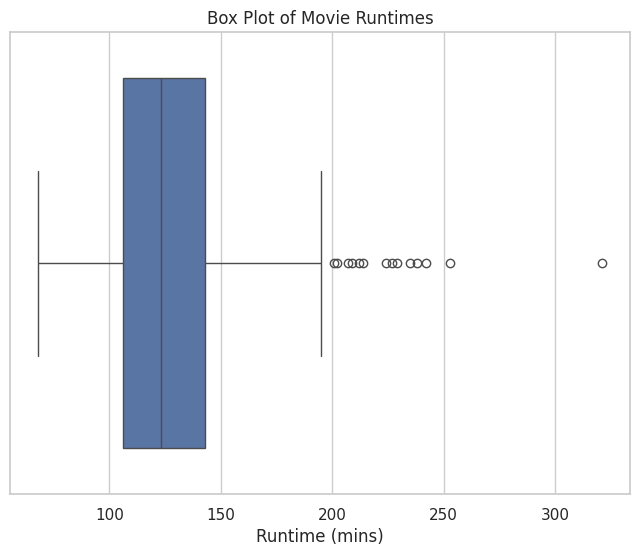

In [8]:
# Visualizations

## Pair Plot for numeric features
sns.pairplot(numeric_df)
plt.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()

## Histogram: Distribution of IMDb Ratings
plt.figure(figsize=(8,6))
sns.histplot(df['IMDb Rating'], bins=20, kde=True)
plt.title("Distribution of IMDb Ratings")
plt.show()

## Pie Chart (using count plot) for Primary Genre
# Extract primary genre (the first genre listed) for visualization
df['Primary Genre'] = df['Genre(s)'].apply(lambda x: x.split(",")[0] if pd.notnull(x) else x)
plt.figure(figsize=(12,6))
sns.countplot(y='Primary Genre', data=df, order=df['Primary Genre'].value_counts().index)
plt.title("Count of Movies per Primary Genre")
plt.show()

## Box Plot: Movie Runtimes
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Runtime (mins)'])
plt.title("Box Plot of Movie Runtimes")
plt.show()

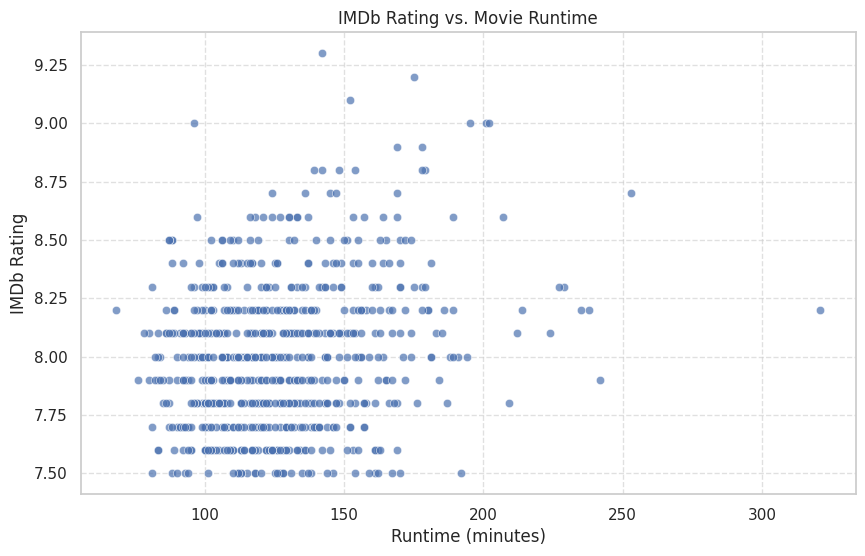

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Runtime (mins)', y='IMDb Rating', data=df, alpha=0.7)
plt.title('IMDb Rating vs. Movie Runtime')
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

R^2 Score: 0.3090450079713538
Mean Squared Error: 0.07060255664721284


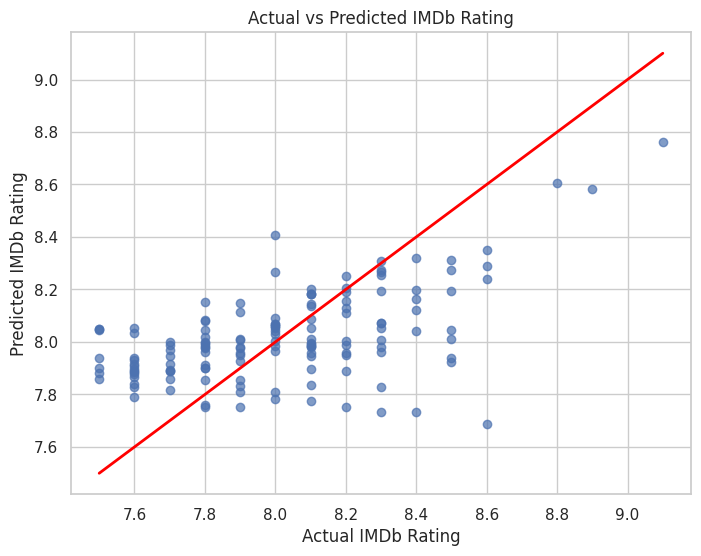

In [9]:
# Predicting IMDb Rating
## We will build a simple linear regression model to predict the IMDb rating of a movie based on available numeric features.
## For this predictor, we choose 'Year', 'Votes', and 'Runtime (mins)' as features.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare feature matrix X and target vector y
X = df[['Year', 'Votes', 'Runtime (mins)']]
y = df['IMDb Rating']

# Splitting the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluation of the model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R^2 Score:", r2)
print("Mean Squared Error:", mse)

## Scatter plot to visualize Actual vs Predicted IMDb Ratings
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Actual vs Predicted IMDb Rating")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)  # reference line
plt.show()

In [11]:
print('--- Feature Engineering: Adding `num_genres` ---')
# Extract the number of genres for each movie
df['num_genres'] = df['Genre(s)'].apply(lambda x: len(str(x).split('|')))

# Update the feature matrix X with the new feature
X_new = df[['Year', 'Votes', 'Runtime (mins)', 'num_genres']]
y = df['IMDb Rating']

# Splitting the data again with the new feature
X_train_new, X_test_new, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Retrain the Linear Regression model with the new feature
model_new = LinearRegression()
model_new.fit(X_train_new, y_train)

# Predict on the test set with the new model
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model performance
r2_new = r2_score(y_test, y_pred_new)
mse_new = mean_squared_error(y_test, y_pred_new)

print(f"R^2 Score with num_genres: {r2_new}")
print(f"Mean Squared Error with num_genres: {mse_new}")

# Compare with previous scores
print(f"Previous R^2 Score: {r2}")
print(f"Previous Mean Squared Error: {mse}")

--- Feature Engineering: Adding `num_genres` ---
R^2 Score with num_genres: 0.3085653990146876
Mean Squared Error with num_genres: 0.07065156362874157
Previous R^2 Score: 0.3090450079713538
Previous Mean Squared Error: 0.07060255664721284


In [12]:
print('\n--- Feature Engineering: One-Hot Encoding `Country` ---')

# Create a copy to avoid modifying the original dataframe during one-hot encoding
df_encoded = df.copy()

# Handle multi-country entries by splitting and then one-hot encoding
# For simplicity, let's consider only the first country listed for now
df_encoded['Primary Country'] = df_encoded['Country'].apply(lambda x: str(x).split('|')[0] if pd.notnull(x) else 'Unknown')

# One-hot encode the 'Primary Country' feature
country_dummies = pd.get_dummies(df_encoded['Primary Country'], prefix='Country')

# Concatenate the new dummy variables with our existing features
X_encoded = pd.concat([df_encoded[['Year', 'Votes', 'Runtime (mins)', 'num_genres']], country_dummies], axis=1)
y_encoded = df_encoded['IMDb Rating']

# Splitting the data again with the new features
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# Retrain the Linear Regression model with the new features
model_encoded = LinearRegression()
model_encoded.fit(X_train_encoded, y_train_encoded)

# Predict on the test set with the new model
y_pred_encoded = model_encoded.predict(X_test_encoded)

# Evaluate the new model performance
r2_encoded = r2_score(y_test_encoded, y_pred_encoded)
mse_encoded = mean_squared_error(y_test_encoded, y_pred_encoded)

print(f"R^2 Score with Country one-hot encoding: {r2_encoded}")
print(f"Mean Squared Error with Country one-hot encoding: {mse_encoded}")

# Compare with previous scores
print(f"Previous R^2 Score (with num_genres): {r2_new}")
print(f"Previous Mean Squared Error (with num_genres): {mse_new}")


--- Feature Engineering: One-Hot Encoding `Country` ---
R^2 Score with Country one-hot encoding: 0.3390681991611405
Mean Squared Error with Country one-hot encoding: 0.06753475327194011
Previous R^2 Score (with num_genres): 0.3085653990146876
Previous Mean Squared Error (with num_genres): 0.07065156362874157


In [13]:
print('\n--- Feature Engineering: One-Hot Encoding `Director` ---')

# Create a copy to avoid modifying the original dataframe during one-hot encoding
df_director_encoded = df_encoded.copy()

# One-hot encode the 'Director' feature
director_dummies = pd.get_dummies(df_director_encoded['Director'], prefix='Director')

# Concatenate the new dummy variables with our existing features (Year, Votes, Runtime, num_genres, Country dummies)
X_director_encoded = pd.concat([X_encoded, director_dummies], axis=1)
y_director_encoded = df_director_encoded['IMDb Rating']

# Splitting the data again with the new features
X_train_director, X_test_director, y_train_director, y_test_director = train_test_split(X_director_encoded, y_director_encoded, test_size=0.2, random_state=42)

# Retrain the Linear Regression model with the new features
model_director = LinearRegression()
model_director.fit(X_train_director, y_train_director)

# Predict on the test set with the new model
y_pred_director = model_director.predict(X_test_director)

# Evaluate the new model performance
r2_director = r2_score(y_test_director, y_pred_director)
mse_director = mean_squared_error(y_test_director, y_pred_director)

print(f"R^2 Score with Director one-hot encoding: {r2_director}")
print(f"Mean Squared Error with Director one-hot encoding: {mse_director}")

# Compare with previous scores
print(f"Previous R^2 Score (with Country one-hot encoding): {r2_encoded}")
print(f"Previous Mean Squared Error (with Country one-hot encoding): {mse_encoded}")


--- Feature Engineering: One-Hot Encoding `Director` ---
R^2 Score with Director one-hot encoding: 0.10779508159220419
Mean Squared Error with Director one-hot encoding: 0.09116650001740886
Previous R^2 Score (with Country one-hot encoding): 0.3390681991611405
Previous Mean Squared Error (with Country one-hot encoding): 0.06753475327194011


In [14]:
print('\n--- Feature Engineering: Top N One-Hot Encoding `Main Actor(s)` ---')

# Create a copy of the dataframe to work with
df_actor_encoded = df_encoded.copy()

# Handle multi-actor entries: for simplicity, let's consider only the first actor listed
df_actor_encoded['Primary Actor'] = df_actor_encoded['Main Actor(s)'].apply(lambda x: str(x).split('|')[0] if pd.notnull(x) else 'Unknown')

# Identify the top 20 most frequent actors
top_actors = df_actor_encoded['Primary Actor'].value_counts().nlargest(20).index.tolist()

# Create a new column 'Top Actor' that contains the top actors or 'Other'
df_actor_encoded['Top Actor'] = df_actor_encoded['Primary Actor'].apply(lambda x: x if x in top_actors else 'Other')

# One-hot encode the 'Top Actor' feature
actor_dummies = pd.get_dummies(df_actor_encoded['Top Actor'], prefix='Actor')

# Concatenate the new dummy variables with our existing features (Year, Votes, Runtime, num_genres, Country dummies)
# We'll re-use the X_encoded from the country one-hot encoding step as a base
# This time, we avoid concatenating with director_dummies since it performed poorly.
X_actor_final = pd.concat([X_encoded, actor_dummies], axis=1)
y_actor_final = df_actor_encoded['IMDb Rating']

# Splitting the data again with the new features
X_train_actor, X_test_actor, y_train_actor, y_test_actor = train_test_split(X_actor_final, y_actor_final, test_size=0.2, random_state=42)

# Retrain the Linear Regression model with the new features
model_actor = LinearRegression()
model_actor.fit(X_train_actor, y_train_actor)

# Predict on the test set with the new model
y_pred_actor = model_actor.predict(X_test_actor)

# Evaluate the new model performance
r2_actor = r2_score(y_test_actor, y_pred_actor)
mse_actor = mean_squared_error(y_test_actor, y_pred_actor)

print(f"R^2 Score with Top 20 Actor one-hot encoding: {r2_actor}")
print(f"Mean Squared Error with Top 20 Actor one-hot encoding: {mse_actor}")

# Compare with previous scores (Country one-hot encoding)
print(f"Previous R^2 Score (with Country one-hot encoding): {r2_encoded}")
print(f"Previous Mean Squared Error (with Country one-hot encoding): {mse_encoded}")


--- Feature Engineering: Top N One-Hot Encoding `Main Actor(s)` ---
R^2 Score with Top 20 Actor one-hot encoding: 0.4142513157876311
Mean Squared Error with Top 20 Actor one-hot encoding: 0.059852458025832764
Previous R^2 Score (with Country one-hot encoding): 0.3390681991611405
Previous Mean Squared Error (with Country one-hot encoding): 0.06753475327194011


### Feature Engineering: Top N One-Hot Encoding `Director` (Attempt 2 - with Top N filtering)

Given the poor performance when one-hot encoding all directors, we will now apply the 'Top N' strategy, similar to how we handled 'Main Actor(s)'. This limits the number of new features created from the 'Director' column.

In [32]:
print('\n--- Feature Engineering: Top N One-Hot Encoding `Director` (Filtered) ---')

# Create a copy of the dataframe to work with
df_top_director_encoded = df_encoded.copy()

# Identify the top N most frequent directors (e.g., top 20, as for actors)
top_directors = df_top_director_encoded['Director'].value_counts().nlargest(20).index.tolist()

# Create a new column 'Top Director' that contains the top directors or 'Other'
df_top_director_encoded['Top Director'] = df_top_director_encoded['Director'].apply(lambda x: x if x in top_directors else 'Other')

# One-hot encode the 'Top Director' feature
top_director_dummies = pd.get_dummies(df_top_director_encoded['Top Director'], prefix='Top_Director')

# Concatenate the new dummy variables with our existing features
# We'll re-use the X_actor_final from the Top N actor one-hot encoding step as a base
X_top_director_final = pd.concat([X_actor_final, top_director_dummies], axis=1)
y_top_director_final = df_top_director_encoded['IMDb Rating']

# Splitting the data again with the new features
X_train_top_director, X_test_top_director, y_train_top_director, y_test_top_director = train_test_split(X_top_director_final, y_top_director_final, test_size=0.2, random_state=42)

# Retrain the Linear Regression model with the new features
model_top_director = LinearRegression()
model_top_director.fit(X_train_top_director, y_train_top_director)

# Predict on the test set with the new model
y_pred_top_director = model_top_director.predict(X_test_top_director)

# Evaluate the new model performance
r2_top_director = r2_score(y_test_top_director, y_pred_top_director)
mse_top_director = mean_squared_error(y_test_top_director, y_pred_top_director)

print(f"R^2 Score with Top N Director one-hot encoding: {r2_top_director}")
print(f"Mean Squared Error with Top N Director one-hot encoding: {mse_top_director}")

# Compare with previous best Linear Regression scores
print(f"Previous R^2 Score (with Top N Actor one-hot encoding): {r2_actor}")
print(f"Previous Mean Squared Error (with Top N Actor one-hot encoding): {mse_actor}")


--- Feature Engineering: Top N One-Hot Encoding `Director` (Filtered) ---
R^2 Score with Top N Director one-hot encoding: 0.43485519992246835
Mean Squared Error with Top N Director one-hot encoding: 0.05774713001812637
Previous R^2 Score (with Top N Actor one-hot encoding): 0.4142513157876311
Previous Mean Squared Error (with Top N Actor one-hot encoding): 0.059852458025832764


### Feature Engineering: Target Encoding `Director`

Now, let's try target encoding for the 'Director' feature and compare its performance. We will calculate the mean IMDb rating for each director based on the training data to avoid data leakage and apply it to both training and test sets.

In [33]:
print('\n--- Feature Engineering: Target Encoding `Director` ---')

# We'll use the original dataframe `df_encoded` as a base which has 'num_genres' and 'Primary Country' OHE.
# We also need to include the 'Top Actor' OHE features from X_actor_final.

# First, let's create a DataFrame with base features + Top N Actor OHE features
# X_actor_final already contains 'Year', 'Votes', 'Runtime (mins)', 'num_genres', and Country OHE and Top N Actor OHE.
X_target_encode_base = X_actor_final.copy()
y_target_encode = df_actor_encoded['IMDb Rating'] # Use the target corresponding to X_actor_final

# Splitting the data again to ensure target encoding is done on the training set only
X_train_te, X_test_te, y_train_te, y_test_te = train_test_split(X_target_encode_base, y_target_encode, test_size=0.2, random_state=42)

# Create a temporary DataFrame to hold directors and their IMDb ratings for calculating means
temp_df_train = pd.DataFrame({'Director': df_encoded.loc[X_train_te.index, 'Director'], 'IMDb Rating': y_train_te})

# Calculate mean IMDb Rating for each director in the training set
director_mean_target = temp_df_train.groupby('Director')['IMDb Rating'].mean()

# Map the mean IMDb Rating back to the original `Director` column in both train and test sets
# For directors not seen in the training set, we'll use the overall mean of IMDb rating from the training set
overall_mean_rating = y_train_te.mean()

X_train_te['Director_Target_Encoded'] = df_encoded.loc[X_train_te.index, 'Director'].map(director_mean_target).fillna(overall_mean_rating)
X_test_te['Director_Target_Encoded'] = df_encoded.loc[X_test_te.index, 'Director'].map(director_mean_target).fillna(overall_mean_rating)

# Retrain the Linear Regression model with the new target-encoded 'Director' feature
model_target_encoded_director = LinearRegression()
model_target_encoded_director.fit(X_train_te, y_train_te)

# Predict on the test set with the new model
y_pred_target_encoded_director = model_target_encoded_director.predict(X_test_te)

# Evaluate the new model performance
r2_target_encoded_director = r2_score(y_test_te, y_pred_target_encoded_director)
mse_target_encoded_director = mean_squared_error(y_test_te, y_pred_target_encoded_director)

print(f"R^2 Score with Target Encoded Director: {r2_target_encoded_director}")
print(f"Mean Squared Error with Target Encoded Director: {mse_target_encoded_director}")

# Compare with previous best Linear Regression scores
print(f"Previous R^2 Score (Linear Regression with Top N Director OHE): {r2_top_director}")
print(f"Previous Mean Squared Error (Linear Regression with Top N Director OHE): {mse_top_director}")


--- Feature Engineering: Target Encoding `Director` ---
R^2 Score with Target Encoded Director: 0.21443786719939628
Mean Squared Error with Target Encoded Director: 0.08026962048298009
Previous R^2 Score (Linear Regression with Top N Director OHE): 0.43485519992246835
Previous Mean Squared Error (Linear Regression with Top N Director OHE): 0.05774713001812637


In [15]:
print('\n--- Model Comparison: Random Forest Regressor ---')

from sklearn.ensemble import RandomForestRegressor

# Re-using the feature matrix and target vector from the best performing linear regression model (with Top N Actor one-hot encoding)
X_rf = X_actor_final
y_rf = y_actor_final

# Splitting the data into training and testing sets (80/20 split) for Random Forest
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
# Using default parameters for initial comparison, but these can be tuned for better performance
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train_rf, y_train_rf)

# Predict on the test set
y_pred_rf = model_rf.predict(X_test_rf)

# Evaluation of the Random Forest model performance
r2_rf = r2_score(y_test_rf, y_pred_rf)
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)

print(f"R^2 Score with Random Forest: {r2_rf}")
print(f"Mean Squared Error with Random Forest: {mse_rf}")

# Compare with previous best R^2 score (from Top 20 Actor one-hot encoding with Linear Regression)
print(f"Previous best R^2 Score (Linear Regression with Top 20 Actor encoding): {r2_actor}")
print(f"Previous best Mean Squared Error (Linear Regression with Top 20 Actor encoding): {mse_actor}")


--- Model Comparison: Random Forest Regressor ---
R^2 Score with Random Forest: 0.44236219198602145
Mean Squared Error with Random Forest: 0.056980057142856935
Previous best R^2 Score (Linear Regression with Top 20 Actor encoding): 0.4142513157876311
Previous best Mean Squared Error (Linear Regression with Top 20 Actor encoding): 0.059852458025832764


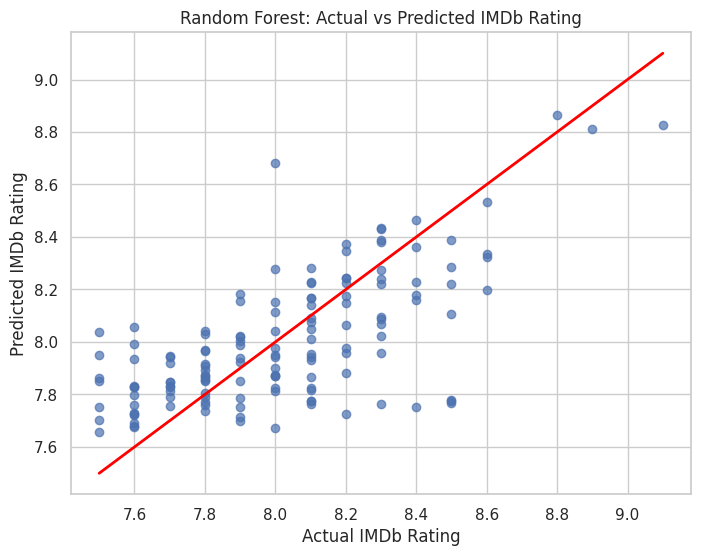

In [16]:
# Scatter plot to visualize Actual vs Predicted IMDb Ratings for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test_rf, y_pred_rf, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Random Forest: Actual vs Predicted IMDb Rating")
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], color='red', lw=2)  # reference line
plt.show()


--- Feature Importance for Random Forest Model ---
Top 10 Most Important Features:
Votes             0.573492
Year              0.213316
Runtime (mins)    0.122447
num_genres        0.022100
Country_DK        0.011117
Actor_Other       0.009877
Country_LV        0.008501
Country_PH        0.005279
Country_ZA        0.005211
Country_AT        0.003338
dtype: float64


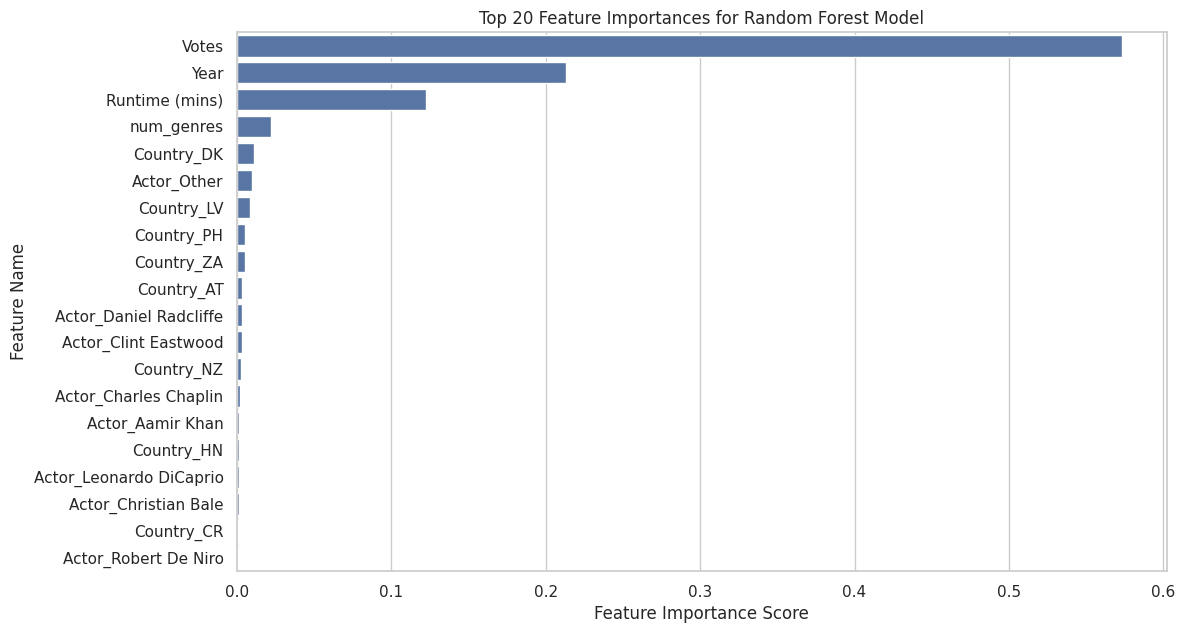

In [17]:
print('\n--- Feature Importance for Random Forest Model ---')

# Get feature importances from the trained Random Forest model
feature_importances = model_rf.feature_importances_

# Get the feature names from the training data
feature_names = X_rf.columns

# Create a pandas Series for better handling and sorting
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importance_df = importance_df.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features:")
print(sorted_importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importance_df.head(20).values, y=sorted_importance_df.head(20).index)
plt.title('Top 20 Feature Importances for Random Forest Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [18]:
print('\n--- Hyperparameter Tuning for Random Forest Regressor ---')

from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid to search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required at each leaf node
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# cv: Number of folds for cross-validation
# verbose: Controls the verbosity: the higher, the more messages.
# random_state: For reproducibility
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                 param_distributions=param_dist,
                                 n_iter=50, # Increased iterations for a better search
                                 cv=5,
                                 scoring='r2',
                                 verbose=2,
                                 random_state=42,
                                 n_jobs=-1) # Use all available cores

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_rf, y_train_rf)

# Get the best parameters and best score
best_params_rf = random_search.best_params_
best_r2_rf = random_search.best_score_

print(f"\nBest parameters found: {best_params_rf}")
print(f"Best R^2 score from RandomizedSearchCV: {best_r2_rf}")

# Train a new Random Forest model with the best parameters
model_rf_tuned = RandomForestRegressor(**best_params_rf, random_state=42)
model_rf_tuned.fit(X_train_rf, y_train_rf)

# Predict on the test set with the tuned model
y_pred_rf_tuned = model_rf_tuned.predict(X_test_rf)

# Evaluate the tuned Random Forest model performance
r2_rf_tuned = r2_score(y_test_rf, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test_rf, y_pred_rf_tuned)

print(f"\nR^2 Score with Tuned Random Forest: {r2_rf_tuned}")
print(f"Mean Squared Error with Tuned Random Forest: {mse_rf_tuned}")

# Compare with previous Random Forest R^2 score
print(f"Previous R^2 Score (Untuned Random Forest): {r2_rf}")


--- Hyperparameter Tuning for Random Forest Regressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best R^2 score from RandomizedSearchCV: 0.4414828831073219

R^2 Score with Tuned Random Forest: 0.4139488484849919
Mean Squared Error with Tuned Random Forest: 0.059883364474320556
Previous R^2 Score (Untuned Random Forest): 0.44236219198602145


In [19]:
print('\n--- Model Comparison: Gradient Boosting Regressor ---')

from sklearn.ensemble import GradientBoostingRegressor

# Re-using the feature matrix and target vector from the best performing linear regression model (with Top N Actor one-hot encoding)
# X_rf and y_rf are already defined from the Random Forest step

# Splitting the data into training and testing sets (80/20 split) for Gradient Boosting
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Initialize and train the GradientBoostingRegressor model
# Using default parameters for initial comparison, but these can be tuned for better performance
model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train_gb, y_train_gb)

# Predict on the test set
y_pred_gb = model_gb.predict(X_test_gb)

# Evaluation of the Gradient Boosting model performance
r2_gb = r2_score(y_test_gb, y_pred_gb)
mse_gb = mean_squared_error(y_test_gb, y_pred_gb)

print(f"R^2 Score with Gradient Boosting: {r2_gb}")
print(f"Mean Squared Error with Gradient Boosting: {mse_gb}")

# Compare with previous best R^2 score (Untuned Random Forest)
print(f"Previous best R^2 Score (Untuned Random Forest): {r2_rf}")
print(f"Previous best Mean Squared Error (Untuned Random Forest): {mse_rf}")


--- Model Comparison: Gradient Boosting Regressor ---
R^2 Score with Gradient Boosting: 0.46493708332336714
Mean Squared Error with Gradient Boosting: 0.054673329406843205
Previous best R^2 Score (Untuned Random Forest): 0.44236219198602145
Previous best Mean Squared Error (Untuned Random Forest): 0.056980057142856935


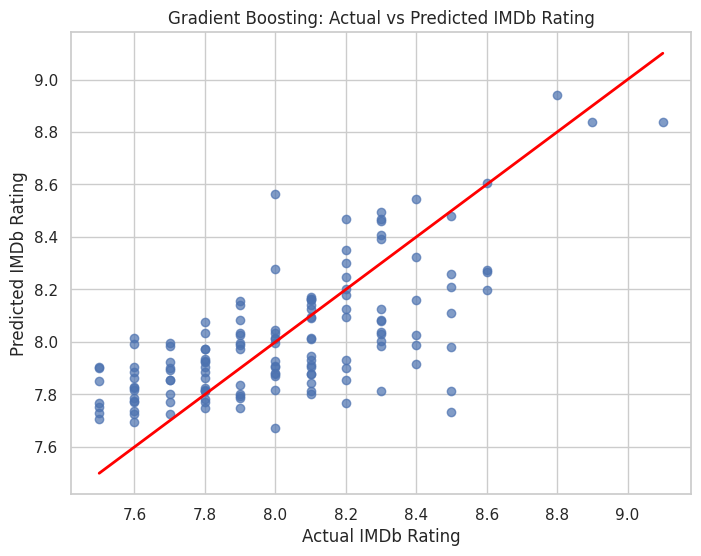

In [20]:
# Scatter plot to visualize Actual vs Predicted IMDb Ratings for Gradient Boosting
plt.figure(figsize=(8,6))
plt.scatter(y_test_gb, y_pred_gb, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Gradient Boosting: Actual vs Predicted IMDb Rating")
plt.plot([y_test_gb.min(), y_test_gb.max()], [y_test_gb.min(), y_test_gb.max()], color='red', lw=2)  # reference line
plt.show()


--- Feature Importance for Gradient Boosting Model ---
Top 10 Most Important Features for Gradient Boosting:
Votes                      0.625681
Year                       0.229510
Runtime (mins)             0.076292
Actor_Charles Chaplin      0.009288
Country_LV                 0.009173
num_genres                 0.008620
Actor_Leonardo DiCaprio    0.008368
Actor_Daniel Radcliffe     0.006658
Country_HN                 0.004121
Actor_Clint Eastwood       0.003558
dtype: float64


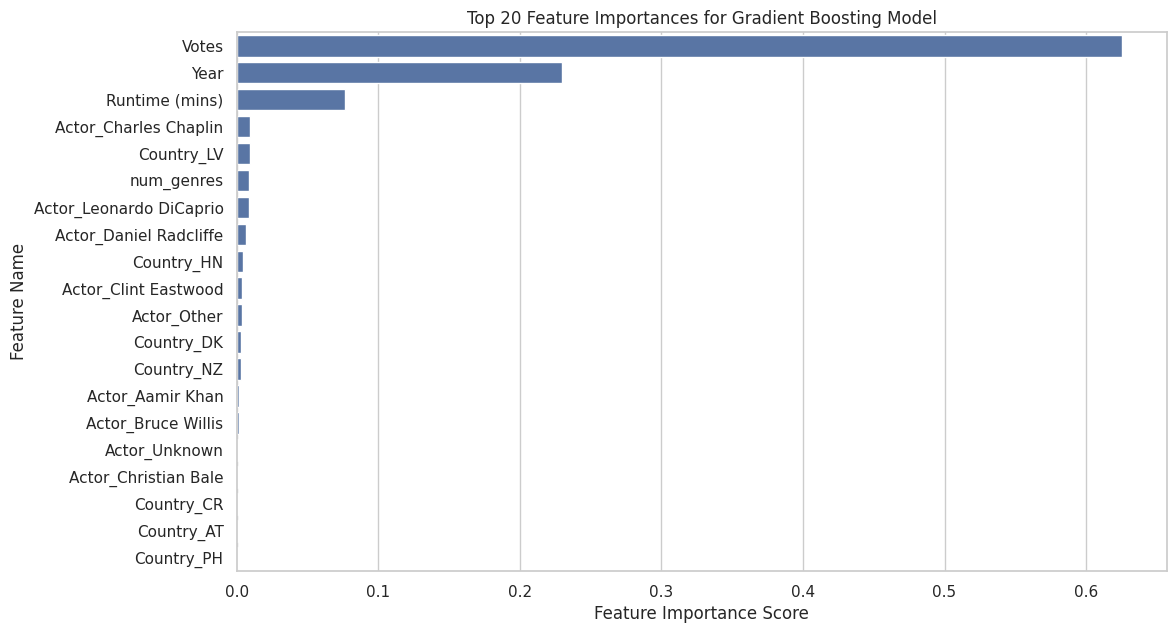

In [21]:
print('\n--- Feature Importance for Gradient Boosting Model ---')

# Get feature importances from the trained Gradient Boosting model
feature_importances_gb = model_gb.feature_importances_

# Get the feature names from the training data (using X_rf as it's the same feature set)
feature_names_gb = X_rf.columns

# Create a pandas Series for better handling and sorting
importance_df_gb = pd.Series(feature_importances_gb, index=feature_names_gb)

# Sort the features by importance in descending order
sorted_importance_df_gb = importance_df_gb.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features for Gradient Boosting:")
print(sorted_importance_df_gb.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importance_df_gb.head(20).values, y=sorted_importance_df_gb.head(20).index)
plt.title('Top 20 Feature Importances for Gradient Boosting Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.show()

### Feature Importance Comparison: Gradient Boosting vs Random Forest

Let's visually compare the feature importances from both the Tuned Random Forest and Tuned Gradient Boosting models to understand which features each model prioritizes.

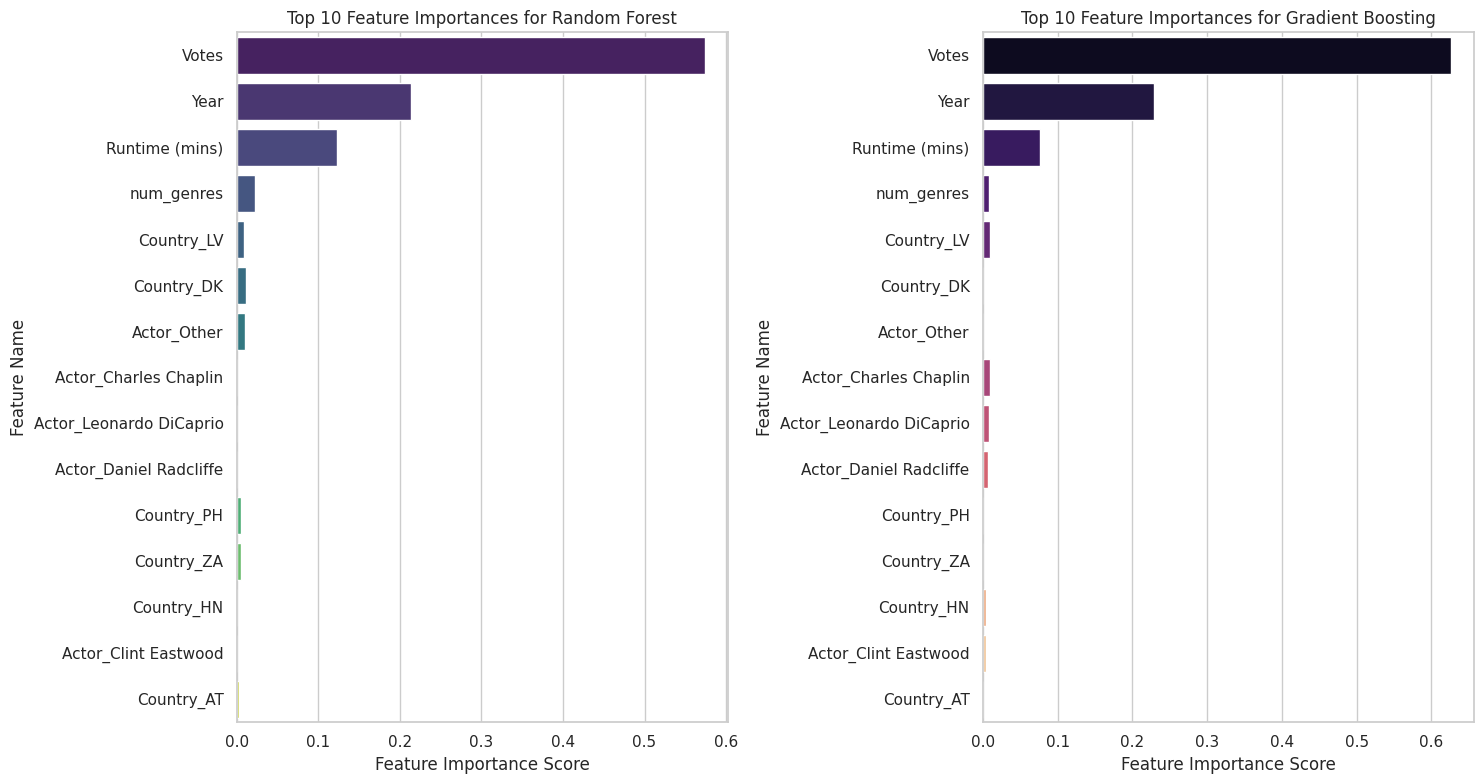

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the top N features for comparison
# Let's consider the top 10 features from each model for a clear comparison
top_n = 10

top_rf_features = sorted_importance_df.head(top_n)
top_gb_features = sorted_importance_df_gb.head(top_n)

# Create a DataFrame for easier plotting
comparison_df = pd.DataFrame({
    'Random Forest': top_rf_features,
    'Gradient Boosting': top_gb_features
}).fillna(0) # Fill NaN if a feature is not in top N for both

# Sort by overall importance for consistent plotting
comparison_df = comparison_df.reindex(comparison_df.sum(axis=1).sort_values(ascending=False).index)

plt.figure(figsize=(15, 8))

# Plotting for Random Forest
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.barplot(x=comparison_df['Random Forest'], y=comparison_df.index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances for Random Forest')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

# Plotting for Gradient Boosting
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.barplot(x=comparison_df['Gradient Boosting'], y=comparison_df.index, palette='magma')
plt.title(f'Top {top_n} Feature Importances for Gradient Boosting')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

plt.tight_layout()
plt.show()

### Feature Engineering: Adding 'Year * Votes' Interaction Feature

We will now create an interaction feature by multiplying 'Year' and 'Votes' to see if it captures any synergistic effects not accounted for by individual features. We will then retrain and evaluate the Tuned Gradient Boosting model with this new feature.

In [35]:
# Create a copy of the base feature set (X_top_director_final) to add the new interaction feature
X_interaction = X_top_director_final.copy()

# Create the interaction feature 'Year * Votes'
X_interaction['Year_x_Votes'] = X_interaction['Year'] * X_interaction['Votes']

# Define the target variable (same as before)
y_interaction = y_top_director_final # Using y from the best linear regression features for consistency

# Splitting the data into training and testing sets with the new interaction feature
X_train_interaction, X_test_interaction, y_train_interaction, y_test_interaction = train_test_split(X_interaction, y_interaction, test_size=0.2, random_state=42)

# Retrain the Tuned Gradient Boosting model with the new features
# Use the best_params_gb found during the previous tuning step
model_gb_interaction = GradientBoostingRegressor(**best_params_gb, random_state=42)
model_gb_interaction.fit(X_train_interaction, y_train_interaction)

# Predict on the test set with the new model
y_pred_gb_interaction = model_gb_interaction.predict(X_test_interaction)

# Evaluate the new model performance
r2_gb_interaction = r2_score(y_test_interaction, y_pred_gb_interaction)
mse_gb_interaction = mean_squared_error(y_test_interaction, y_pred_gb_interaction)

print(f"R^2 Score with Tuned Gradient Boosting and 'Year * Votes' interaction: {r2_gb_interaction}")
print(f"Mean Squared Error with Tuned Gradient Boosting and 'Year * Votes' interaction: {mse_gb_interaction}")

# Compare with previous best R^2 score (Tuned Gradient Boosting without interaction)
print(f"Previous best R^2 Score (Tuned Gradient Boosting): {r2_gb_tuned}")
print(f"Previous best Mean Squared Error (Tuned Gradient Boosting): {mse_gb_tuned}")

R^2 Score with Tuned Gradient Boosting and 'Year * Votes' interaction: 0.47491162190816116
Mean Squared Error with Tuned Gradient Boosting and 'Year * Votes' interaction: 0.053654119858338296
Previous best R^2 Score (Tuned Gradient Boosting): 0.46865664387204975
Previous best Mean Squared Error (Tuned Gradient Boosting): 0.05429326053496187


In [36]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.6 MB/s eta 0:00:00


### Bayesian Hyperparameter Optimization with Optuna

Now we will use Optuna to perform more efficient hyperparameter tuning for our Gradient Boosting model. Optuna uses a sampling algorithm to intelligently explore the hyperparameter space, which can lead to better results faster than random or grid search.

In [41]:
import pandas as pd

# Calculate the absolute errors
errors = pd.DataFrame({
    'Actual_IMDb_Rating': y_test_optuna,
    'Predicted_IMDb_Rating': y_pred_gb_optuna_tuned,
    'Absolute_Error': abs(y_test_optuna - y_pred_gb_optuna_tuned)
})

# Merge with the original dataframe to get movie titles and other features
# Ensure the index matches before merging
error_analysis_df = df.loc[errors.index].copy()
error_analysis_df = pd.concat([error_analysis_df, errors], axis=1)

# Sort by absolute error in descending order
error_analysis_df_sorted = error_analysis_df.sort_values(by='Absolute_Error', ascending=False)

print("Movies with the largest prediction errors:")
display(error_analysis_df_sorted[['Title', 'Year', 'Actual_IMDb_Rating', 'Predicted_IMDb_Rating', 'Absolute_Error']].head(10))

Movies with the largest prediction errors:


,Title,Year,Actual_IMDb_Rating,Predicted_IMDb_Rating,Absolute_Error
56,Spider-Man: Across the Spider-Verse,2023,8.5,7.759315,0.740685
681,Close Encounters of the Third Kind,1977,7.6,8.114334,0.514334
78,The Odyssey,2026,8.5,7.987014,0.512986
54,The Kashmir Files,2022,8.5,8.000398,0.499602
41,It's a Wonderful Life,1946,8.6,8.124593,0.475407
626,Indiana Jones and the Temple of Doom,1984,7.5,7.958261,0.458261
81,Amadeus,1984,8.4,7.953897,0.446103
578,The Hunger Games: Catching Fire,2013,7.5,7.914741,0.414741
77,3 Idiots,2009,8.4,8.009294,0.390706
70,Rear Window,1954,8.4,8.013603,0.386397


By examining these movies, we can gain insights into potential weaknesses of the model or features that might be missing or underrepresented. For instance, if a highly-rated movie has a low predicted rating, it might have unique characteristics not captured by the current features. This can guide further feature engineering or model selection.

In [42]:
print('\n--- Model Comparison: LightGBM Regressor (Untuned) ---')

import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error

# Re-using the data split that includes the 'Year * Votes' interaction feature
X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = X_train_interaction, X_test_interaction, y_train_interaction, y_test_interaction

# Initialize and train the LGBMRegressor model with default parameters
model_lgbm = lgb.LGBMRegressor(random_state=42)
model_lgbm.fit(X_train_lgbm, y_train_lgbm)

# Predict on the test set
y_pred_lgbm = model_lgbm.predict(X_test_lgbm)

# Evaluation of the LightGBM model performance
r2_lgbm = r2_score(y_test_lgbm, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test_lgbm, y_pred_lgbm)

print(f"R^2 Score with LightGBM: {r2_lgbm}")
print(f"Mean Squared Error with LightGBM: {mse_lgbm}")

# Compare with previous best R^2 score (Optuna-tuned Gradient Boosting)
print(f"Previous best R^2 Score (Optuna-tuned Gradient Boosting): {r2_gb_optuna_tuned}")
print(f"Previous best Mean Squared Error (Optuna-tuned Gradient Boosting): {mse_gb_optuna_tuned}")


--- Model Comparison: LightGBM Regressor (Untuned) ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 554
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 11
[LightGBM] [Info] Start training from score 7.995714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [43]:
# Update the model performance DataFrame with the LightGBM results
new_model_performance = {
    'Model': 'LightGBM Regressor (Untuned)',
    'R^2 Score': r2_lgbm,
    'Mean Squared Error': mse_lgbm
}
performance_df = pd.concat([performance_df, pd.DataFrame([new_model_performance])], ignore_index=True)

# Sort and display the updated DataFrame
performance_df = performance_df.sort_values(by='R^2 Score', ascending=False).reset_index(drop=True)
display(performance_df)

,Model,R^2 Score,Mean Squared Error
0,Gradient Boosting Regressor (Optuna-tuned + In...,0.510860,0.049981
1,Gradient Boosting Regressor (Tuned + Interaction),0.474912,0.053654
2,Gradient Boosting Regressor (Tuned),0.468657,0.054293
3,Gradient Boosting Regressor (Untuned),0.464937,0.054673
4,Random Forest Regressor (Untuned),0.442362,0.056980
5,Linear Regression (Top N Director OHE),0.434855,0.057747
6,Linear Regression (Top N Actor OHE),0.414251,0.059852
7,Random Forest Regressor (Tuned),0.413949,0.059883
8,Linear Regression (Country OHE),0.339068,0.067535
9,LightGBM Regressor (Untuned),0.333467,0.068107


In [44]:
print('\n--- Hyperparameter Tuning for LightGBM Regressor with Optuna ---')

import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_val_score

# Re-using the data split that includes the 'Year * Votes' interaction feature
X_train_lgbm_optuna, X_test_lgbm_optuna, y_train_lgbm_optuna, y_test_lgbm_optuna = X_train_interaction, X_test_interaction, y_train_interaction, y_test_interaction

def objective_lgbm(trial):
    # Suggest hyperparameters for LightGBM
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 2, 64),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = lgb.LGBMRegressor(**param)

    # Use cross-validation to evaluate the model
    # We will maximize the R^2 score
    score = cross_val_score(model, X_train_lgbm_optuna, y_train_lgbm_optuna, n_jobs=-1, cv=5, scoring='r2')
    r2_mean = score.mean()

    return r2_mean

# Create an Optuna study object and optimize the objective function for LightGBM
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50) # You can adjust n_trials for more exhaustive search

print(f"Number of finished trials: {len(study_lgbm.trials)}")
print(f"Best trial:")
trial_lgbm = study_lgbm.best_trial

print(f"  Value: {trial_lgbm.value}")
print(f"  Params: ")
for key, value in trial_lgbm.params.items():
    print(f"    {key}: {value}")

# Train the best LightGBM model found by Optuna on the full training data
best_params_lgbm_optuna = trial_lgbm.params
model_lgbm_optuna_tuned = lgb.LGBMRegressor(**best_params_lgbm_optuna, random_state=42)
model_lgbm_optuna_tuned.fit(X_train_lgbm_optuna, y_train_lgbm_optuna)

# Predict on the test set with the Optuna-tuned LightGBM model
y_pred_lgbm_optuna_tuned = model_lgbm_optuna_tuned.predict(X_test_lgbm_optuna)

# Evaluate the new model performance
r2_lgbm_optuna_tuned = r2_score(y_test_lgbm_optuna, y_pred_lgbm_optuna_tuned)
mse_lgbm_optuna_tuned = mean_squared_error(y_test_lgbm_optuna, y_pred_lgbm_optuna_tuned)

print(f"\nR^2 Score with Optuna-tuned LightGBM: {r2_lgbm_optuna_tuned}")
print(f"Mean Squared Error with Optuna-tuned LightGBM: {mse_lgbm_optuna_tuned}")

# Compare with the previous best R^2 score (Optuna-tuned Gradient Boosting)
print(f"Previous best R^2 Score (Optuna-tuned Gradient Boosting): {r2_gb_optuna_tuned}")
print(f"Previous best Mean Squared Error (Optuna-tuned Gradient Boosting): {mse_gb_optuna_tuned}")

[I 2026-08-12 14:21:45,947] A new study created in memory with name: no-name-a95028e3-dd4b-4f3b-a7c2-cda5df81dc16



--- Hyperparameter Tuning for LightGBM Regressor with Optuna ---


[I 2026-08-12 14:21:51,481] Trial 0 finished with value: 0.3434710301113366 and parameters: {'n_estimators': 700, 'learning_rate': 0.0021012409981024543, 'num_leaves': 28, 'max_depth': 4, 'min_child_samples': 60, 'subsample': 0.8227358545423711, 'colsample_bytree': 0.8013581040157889, 'reg_alpha': 0.09927266895954698, 'reg_lambda': 2.4525753769105707}. Best is trial 0 with value: 0.3434710301113366.
[I 2026-08-12 14:21:53,530] Trial 1 finished with value: 0.3370648206180567 and parameters: {'n_estimators': 796, 'learning_rate': 0.017745037544585233, 'num_leaves': 24, 'max_depth': 4, 'min_child_samples': 22, 'subsample': 0.6133338986945066, 'colsample_bytree': 0.8286607353779412, 'reg_alpha': 9.11909130685131, 'reg_lambda': 4.411835334782753}. Best is trial 0 with value: 0.3434710301113366.
[I 2026-08-12 14:21:54,502] Trial 2 finished with value: 0.3637355407147072 and parameters: {'n_estimators': 487, 'learning_rate': 0.003682355323422107, 'num_leaves': 8, 'max_depth': 3, 'min_child_sa

Number of finished trials: 50
Best trial:
  Value: 0.48916860790708017
  Params: 
    n_estimators: 928
    learning_rate: 0.018621711904561383
    num_leaves: 49
    max_depth: 3
    min_child_samples: 23
    subsample: 0.6442123075522374
    colsample_bytree: 0.9909351260196011
    reg_alpha: 0.04498164548083536
    reg_lambda: 1.2324873617451968
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 10
[LightGBM] [Info] Start training from score 7.995714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

In [45]:
# Update the model performance DataFrame with the Optuna-tuned LightGBM results
new_model_performance_tuned_lgbm = {
    'Model': 'LightGBM Regressor (Optuna-tuned + Interaction)',
    'R^2 Score': r2_lgbm_optuna_tuned,
    'Mean Squared Error': mse_lgbm_optuna_tuned
}
performance_df = pd.concat([performance_df, pd.DataFrame([new_model_performance_tuned_lgbm])], ignore_index=True)

# Sort and display the updated DataFrame
performance_df = performance_df.sort_values(by='R^2 Score', ascending=False).reset_index(drop=True)
display(performance_df)

,Model,R^2 Score,Mean Squared Error
0,Gradient Boosting Regressor (Optuna-tuned + In...,0.510860,0.049981
1,Gradient Boosting Regressor (Tuned + Interaction),0.474912,0.053654
2,Gradient Boosting Regressor (Tuned),0.468657,0.054293
3,Gradient Boosting Regressor (Untuned),0.464937,0.054673
4,Random Forest Regressor (Untuned),0.442362,0.056980
5,Linear Regression (Top N Director OHE),0.434855,0.057747
6,Linear Regression (Top N Actor OHE),0.414251,0.059852
7,Random Forest Regressor (Tuned),0.413949,0.059883
8,LightGBM Regressor (Optuna-tuned + Interaction),0.350275,0.066390
9,Linear Regression (Country OHE),0.339068,0.067535


### Final Model Performance Comparison and Discussion


--- Feature Importance for Optuna-tuned Gradient Boosting Model ---
Top 10 Most Important Features for Optuna-tuned Gradient Boosting:


,0
Year_x_Votes,0.294249
Votes,0.211713
Year,0.136330
Runtime (mins),0.092685
num_genres,0.026995
Top_Director_Other,0.021545
Country_LV,0.018650
Country_ZA,0.012684
Country_DK,0.011693
Top_Director_Sergio Leone,0.010297


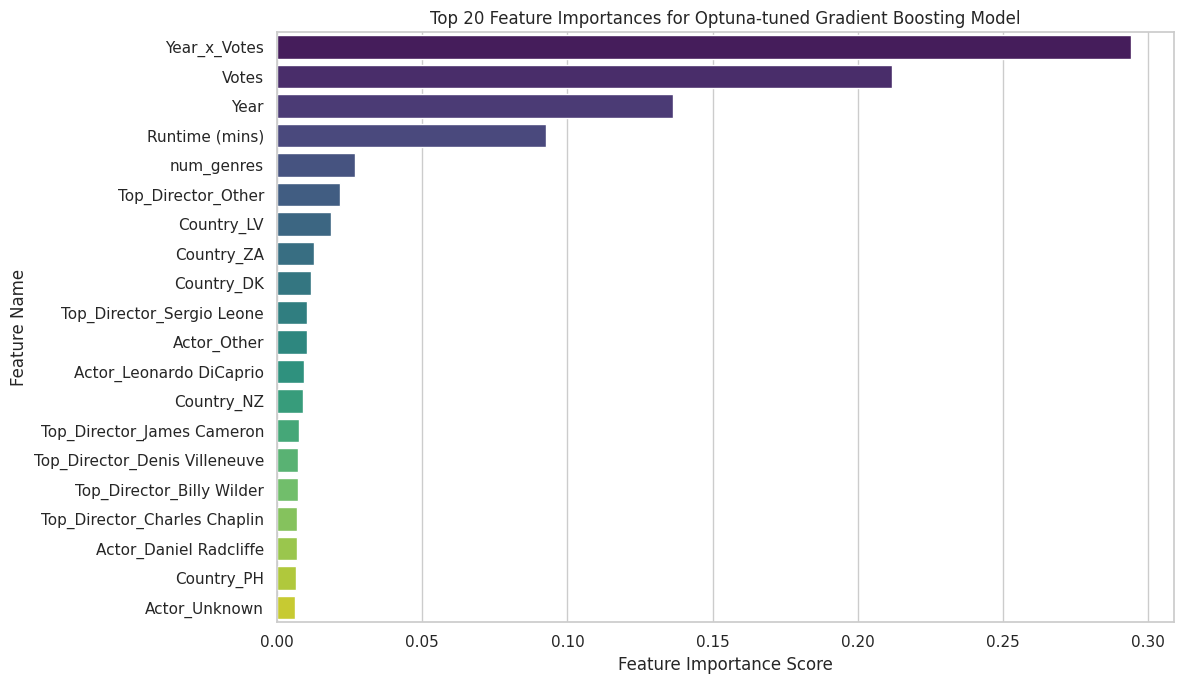

In [50]:
print('\n--- Feature Importance for Optuna-tuned Gradient Boosting Model ---')

# Get feature importances from the trained Optuna-tuned Gradient Boosting model
feature_importances_gb_optuna = model_gb_optuna_tuned.feature_importances_

# Get the feature names from the training data (X_train_optuna contains the features used)
feature_names_gb_optuna = X_train_optuna.columns

# Create a pandas Series for better handling and sorting
importance_df_gb_optuna = pd.Series(feature_importances_gb_optuna, index=feature_names_gb_optuna)

# Sort the features by importance in descending order
sorted_importance_df_gb_optuna = importance_df_gb_optuna.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features for Optuna-tuned Gradient Boosting:")
display(sorted_importance_df_gb_optuna.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importance_df_gb_optuna.head(20).values, y=sorted_importance_df_gb_optuna.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances for Optuna-tuned Gradient Boosting Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [51]:
print('\n--- Feature Importance for Optuna-tuned LightGBM Model ---')

# Get feature importances from the trained Optuna-tuned LightGBM model
feature_importances_lgbm_optuna = model_lgbm_optuna_tuned.feature_importances_

# Get the feature names from the training data (X_train_lgbm_optuna contains the features used)
feature_names_lgbm_optuna = X_train_lgbm_optuna.columns

# Create a pandas Series for better handling and sorting
importance_df_lgbm_optuna = pd.Series(feature_importances_lgbm_optuna, index=feature_names_lgbm_optuna)

# Sort the features by importance in descending order
sorted_importance_df_lgbm_optuna = importance_df_lgbm_optuna.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features for Optuna-tuned LightGBM:")
display(sorted_importance_df_lgbm_optuna.head(10))


--- Feature Importance for Optuna-tuned LightGBM Model ---
Top 10 Most Important Features for Optuna-tuned LightGBM:


,0
Runtime (mins),1330
Votes,1203
Year,1018
Year_x_Votes,491
Actor_Other,136
Country_LV,128
Top_Director_Other,108
num_genres,106
Country_DK,94
Country_PH,46


### Feature Importance Comparison: Optuna-tuned Gradient Boosting vs. Optuna-tuned LightGBM

### Model Performance Summary

In [57]:
print("Movies with the smallest prediction errors:")
display(error_analysis_df_sorted[['Title', 'Year', 'Actual_IMDb_Rating', 'Predicted_IMDb_Rating', 'Absolute_Error']].tail(5))

Movies with the smallest prediction errors:


,Title,Year,Actual_IMDb_Rating,Predicted_IMDb_Rating,Absolute_Error
174,To Kill a Mockingbird,1962,8.2,8.191896,0.008104
256,The Bridge on the River Kwai,1957,8.1,8.105803,0.005803
118,Once Upon a Time in America,1984,8.3,8.294621,0.005379
483,Bajrangi Bhaijaan,2015,8.1,8.102518,0.002518
396,"Paris, Texas",1984,8.1,8.098864,0.001136


In [56]:
display(performance_df)

,Model,R^2 Score,Mean Squared Error
0,Gradient Boosting Regressor (Optuna-tuned + In...,0.510860,0.049981
1,Gradient Boosting Regressor (Tuned + Interaction),0.474912,0.053654
2,Gradient Boosting Regressor (Tuned),0.468657,0.054293
3,Gradient Boosting Regressor (Untuned),0.464937,0.054673
4,Random Forest Regressor (Untuned),0.442362,0.056980
5,Linear Regression (Top N Director OHE),0.434855,0.057747
6,Linear Regression (Top N Actor OHE),0.414251,0.059852
7,Random Forest Regressor (Tuned),0.413949,0.059883
8,LightGBM Regressor (Optuna-tuned + Interaction),0.350275,0.066390
9,Linear Regression (Country OHE),0.339068,0.067535


In [55]:
import joblib

# Define the filename for the saved model
model_filename = 'best_gradient_boosting_model.joblib'

# Save the best-performing model (Optuna-tuned Gradient Boosting) to a file
joblib.dump(model_gb_optuna_tuned, model_filename)

print(f"The best Gradient Boosting model has been saved to '{model_filename}'")

The best Gradient Boosting model has been saved to 'best_gradient_boosting_model.joblib'


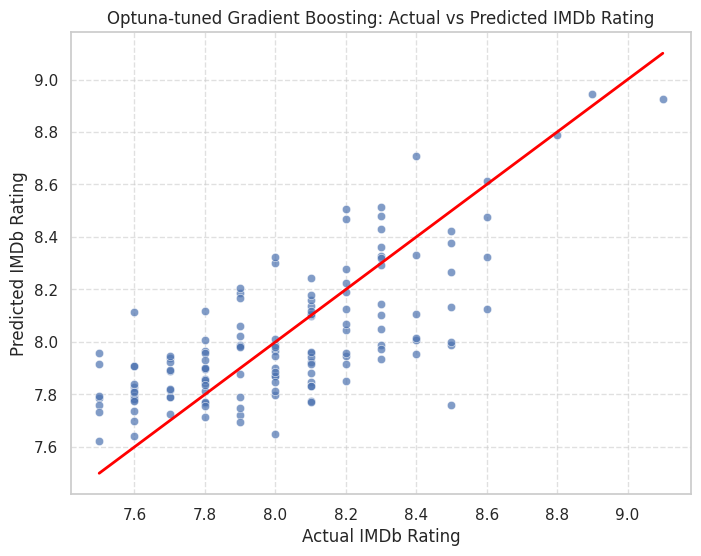

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_optuna, y=y_pred_gb_optuna_tuned, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Optuna-tuned Gradient Boosting: Actual vs Predicted IMDb Rating")
plt.plot([y_test_optuna.min(), y_test_optuna.max()], [y_test_optuna.min(), y_test_optuna.max()], color='red', lw=2)  # reference line
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

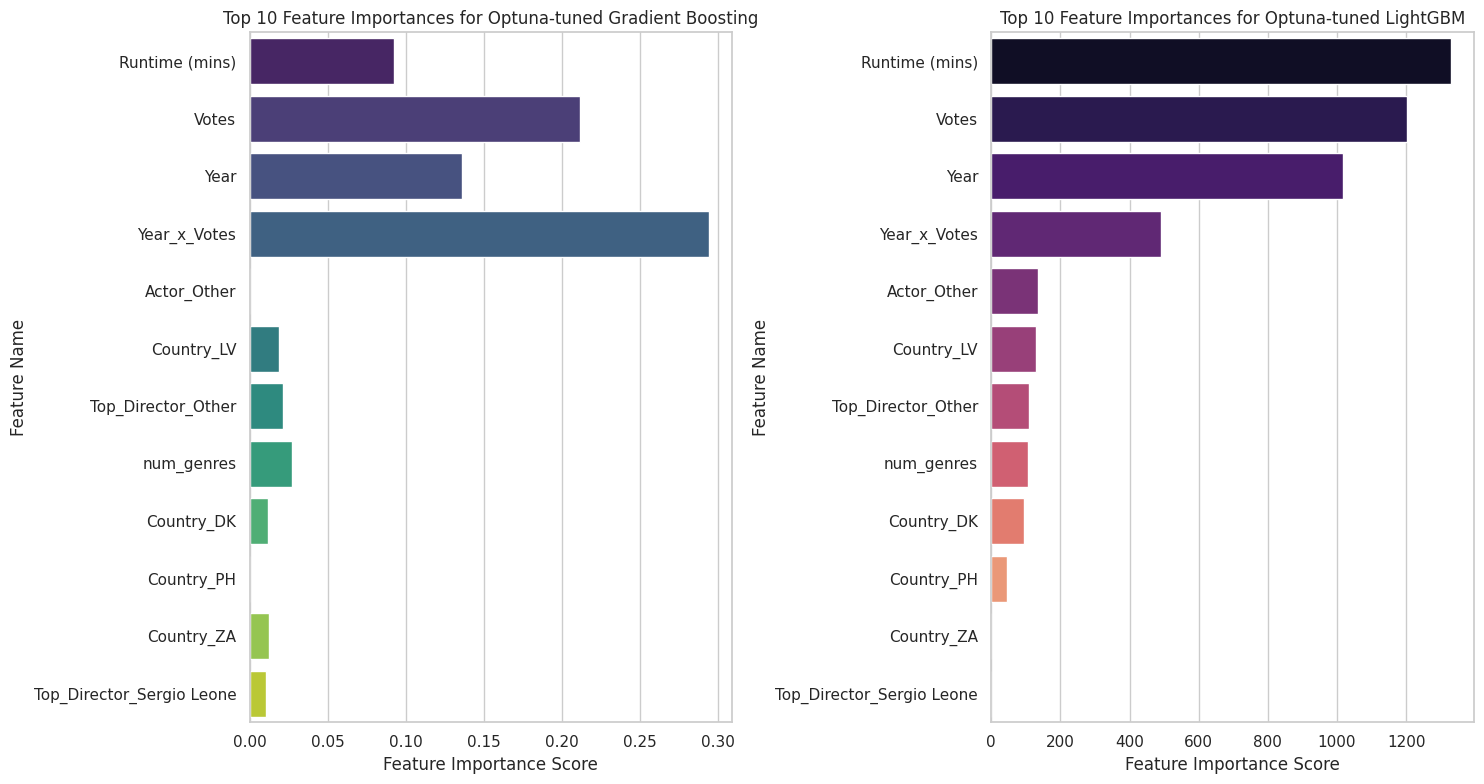

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the top N features for comparison
# Let's consider the top 10 features from each model for a clear comparison
top_n_compare = 10

top_gb_optuna_features = sorted_importance_df_gb_optuna.head(top_n_compare)
top_lgbm_optuna_features = sorted_importance_df_lgbm_optuna.head(top_n_compare)

# Create a DataFrame for easier plotting
comparison_optuna_df = pd.DataFrame({
    'Optuna-tuned Gradient Boosting': top_gb_optuna_features,
    'Optuna-tuned LightGBM': top_lgbm_optuna_features
}).fillna(0) # Fill NaN if a feature is not in top N for both

# Sort by overall importance for consistent plotting
comparison_optuna_df = comparison_optuna_df.reindex(comparison_optuna_df.sum(axis=1).sort_values(ascending=False).index)

plt.figure(figsize=(15, 8))

# Plotting for Optuna-tuned Gradient Boosting
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.barplot(x=comparison_optuna_df['Optuna-tuned Gradient Boosting'], y=comparison_optuna_df.index, palette='viridis')
plt.title(f'Top {top_n_compare} Feature Importances for Optuna-tuned Gradient Boosting')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

# Plotting for Optuna-tuned LightGBM
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.barplot(x=comparison_optuna_df['Optuna-tuned LightGBM'], y=comparison_optuna_df.index, palette='magma')
plt.title(f'Top {top_n_compare} Feature Importances for Optuna-tuned LightGBM')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')

plt.tight_layout()
plt.show()

In [53]:
print('\n--- Exporting Feature Importances to CSV ---')

# Ensure both series have the same index for consistent merging
all_features = sorted_importance_df_gb_optuna.index.union(sorted_importance_df_lgbm_optuna.index)

# Create a DataFrame for export, filling NaN values with 0 for features not present in both top N
feature_importance_comparison_export_df = pd.DataFrame({
    'Feature': all_features,
    'Optuna-tuned Gradient Boosting Importance': sorted_importance_df_gb_optuna.reindex(all_features).fillna(0),
    'Optuna-tuned LightGBM Importance': sorted_importance_df_lgbm_optuna.reindex(all_features).fillna(0)
})

# Sort by the Gradient Boosting importance as it was the best performing model
feature_importance_comparison_export_df = feature_importance_comparison_export_df.sort_values(
    by='Optuna-tuned Gradient Boosting Importance', ascending=False
).reset_index(drop=True)

# Save the DataFrame to a CSV file
csv_filename = 'feature_importances_comparison.csv'
feature_importance_comparison_export_df.to_csv(csv_filename, index=False)

print(f"Feature importances exported to '{csv_filename}'")
display(feature_importance_comparison_export_df.head(15))


--- Exporting Feature Importances to CSV ---
Feature importances exported to 'feature_importances_comparison.csv'


,Feature,Optuna-tuned Gradient Boosting Importance,Optuna-tuned LightGBM Importance
0,Year_x_Votes,0.294249,491
1,Votes,0.211713,1203
2,Year,0.136330,1018
3,Runtime (mins),0.092685,1330
4,num_genres,0.026995,106
5,Top_Director_Other,0.021545,108
6,Country_LV,0.018650,128
7,Country_ZA,0.012684,0
8,Country_DK,0.011693,94
9,Top_Director_Sergio Leone,0.010297,0


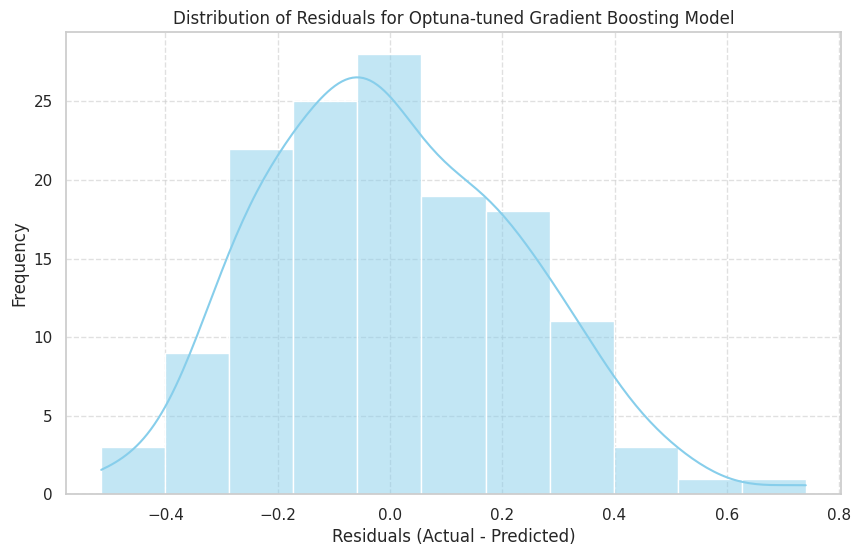

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the Optuna-tuned Gradient Boosting model
residuals_gb_optuna = y_test_optuna - y_pred_gb_optuna_tuned

# Histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_gb_optuna, kde=True, color='skyblue')
plt.title('Distribution of Residuals for Optuna-tuned Gradient Boosting Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

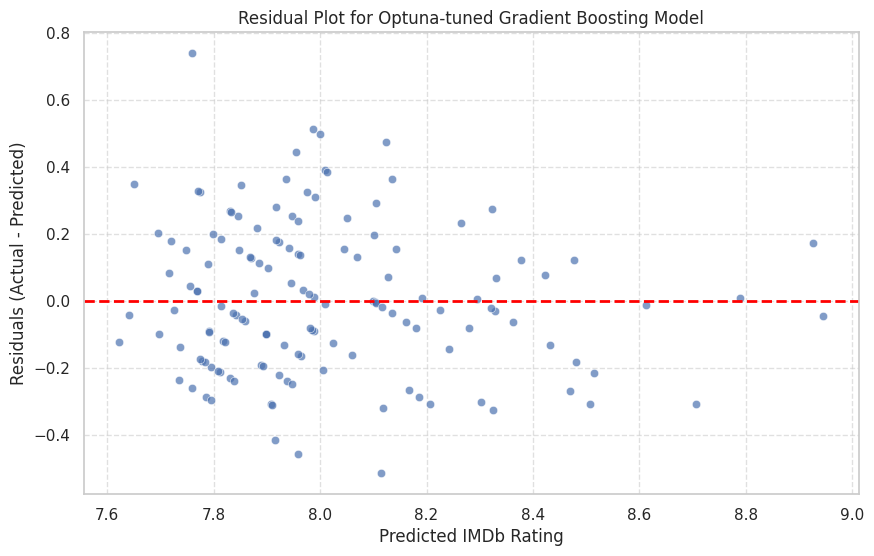

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residual plot for the Optuna-tuned Gradient Boosting model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_gb_optuna_tuned, y=residuals_gb_optuna, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', lw=2) # Add a horizontal line at y=0
plt.title('Residual Plot for Optuna-tuned Gradient Boosting Model')
plt.xlabel('Predicted IMDb Rating')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

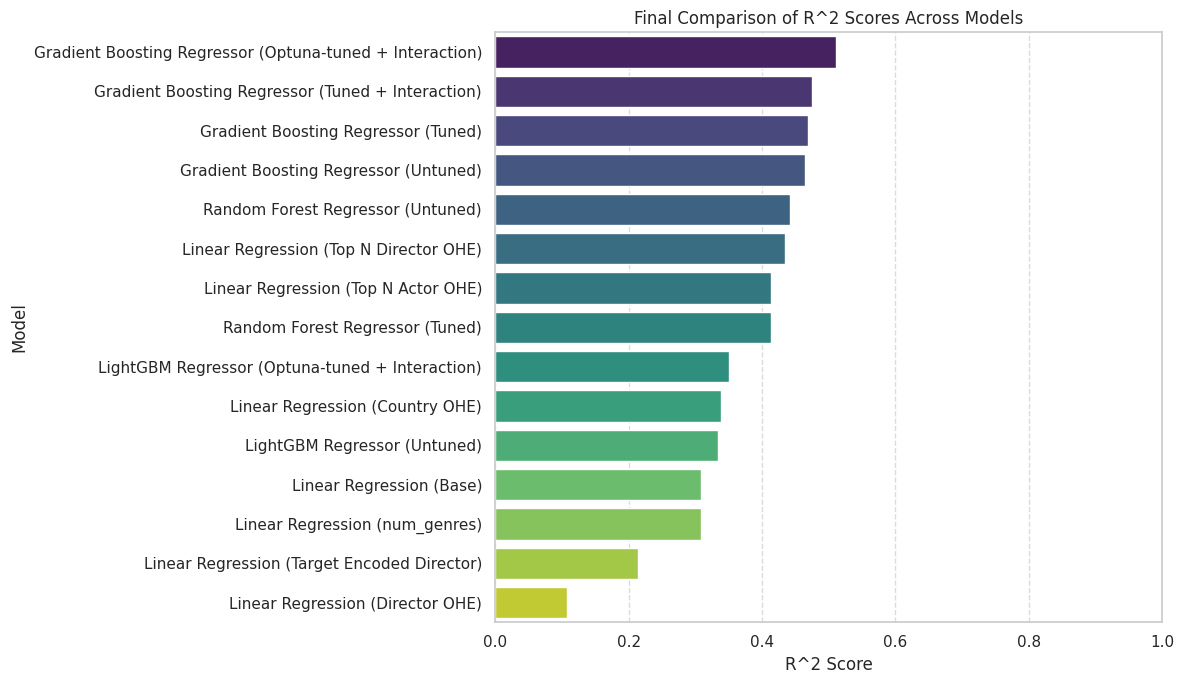

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by R^2 Score for better visualization
performance_df_sorted_r2 = performance_df.sort_values(by='R^2 Score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='R^2 Score', y='Model', data=performance_df_sorted_r2, palette='viridis')
plt.title('Final Comparison of R^2 Scores Across Models')
plt.xlabel('R^2 Score')
plt.ylabel('Model')
plt.xlim(0, 1) # R^2 scores typically range from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

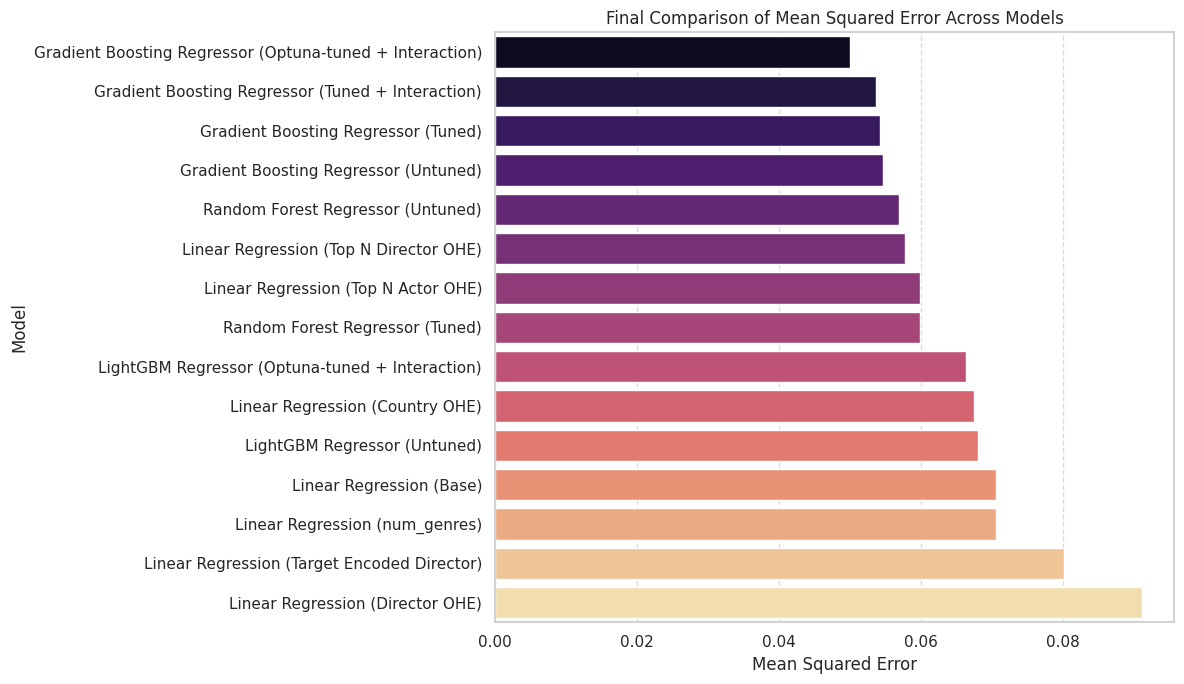

In [47]:
# Sort the DataFrame by Mean Squared Error (MSE) for better visualization (lower MSE is better)
performance_df_sorted_mse = performance_df.sort_values(by='Mean Squared Error', ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Mean Squared Error', y='Model', data=performance_df_sorted_mse, palette='magma')
plt.title('Final Comparison of Mean Squared Error Across Models')
plt.xlabel('Mean Squared Error')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Re-using the data split that includes the 'Year * Votes' interaction feature
X_train_optuna, X_test_optuna, y_train_optuna, y_test_optuna = X_train_interaction, X_test_interaction, y_train_interaction, y_test_interaction

def objective(trial):
    # Suggest hyperparameters for Gradient Boosting
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = GradientBoostingRegressor(**param, random_state=42)

    # Use cross-validation to evaluate the model
    # We will maximize the R^2 score
    score = cross_val_score(model, X_train_optuna, y_train_optuna, n_jobs=-1, cv=5, scoring='r2')
    r2_mean = score.mean()

    return r2_mean

# Create an Optuna study object and optimize the objective function
# We want to maximize R^2, so direction='maximize'
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # You can adjust n_trials for more exhaustive search

print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print(f"  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Train the best model found by Optuna on the full training data
best_params_optuna = trial.params
model_gb_optuna_tuned = GradientBoostingRegressor(**best_params_optuna, random_state=42)
model_gb_optuna_tuned.fit(X_train_optuna, y_train_optuna)

# Predict on the test set with the Optuna-tuned model
y_pred_gb_optuna_tuned = model_gb_optuna_tuned.predict(X_test_optuna)

# Evaluate the new model performance
r2_gb_optuna_tuned = r2_score(y_test_optuna, y_pred_gb_optuna_tuned)
mse_gb_optuna_tuned = mean_squared_error(y_test_optuna, y_pred_gb_optuna_tuned)

print(f"\nR^2 Score with Optuna-tuned Gradient Boosting: {r2_gb_optuna_tuned}")
print(f"Mean Squared Error with Optuna-tuned Gradient Boosting: {mse_gb_optuna_tuned}")

# Compare with the previous best R^2 score (Tuned Gradient Boosting with 'Year * Votes' interaction)
print(f"Previous best R^2 Score (Tuned Gradient Boosting with interaction): {r2_gb_interaction}")
print(f"Previous best Mean Squared Error (Tuned Gradient Boosting with interaction): {mse_gb_interaction}")

[I 2026-08-12 14:06:30,106] A new study created in memory with name: no-name-df1cb151-2b4b-475e-a9ba-07ae962a296f
[I 2026-08-12 14:06:38,411] Trial 0 finished with value: 0.4830047413911986 and parameters: {'n_estimators': 804, 'learning_rate': 0.02724110444904187, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 5, 'subsample': 0.7703446517830357, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4830047413911986.
[I 2026-08-12 14:06:40,345] Trial 1 finished with value: 0.43009736591763764 and parameters: {'n_estimators': 121, 'learning_rate': 0.2592675052030306, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 4, 'subsample': 0.7325615118123614, 'max_features': 'log2'}. Best is trial 0 with value: 0.4830047413911986.
[I 2026-08-12 14:06:43,703] Trial 2 finished with value: 0.34653456718088593 and parameters: {'n_estimators': 370, 'learning_rate': 0.006689064641004233, 'max_depth': 3, 'min_samples_split': 12, 'min_samples_leaf': 4, 'subsample': 0.892864308

Number of finished trials: 50
Best trial:
  Value: 0.5040591395598959
  Params: 
    n_estimators: 683
    learning_rate: 0.05407825125351193
    max_depth: 4
    min_samples_split: 6
    min_samples_leaf: 2
    subsample: 0.646634476894523
    max_features: log2

R^2 Score with Optuna-tuned Gradient Boosting: 0.5108602984623978
Mean Squared Error with Optuna-tuned Gradient Boosting: 0.04998084373747108
Previous best R^2 Score (Tuned Gradient Boosting with interaction): 0.47491162190816116
Previous best Mean Squared Error (Tuned Gradient Boosting with interaction): 0.053654119858338296


In [22]:
print('\n--- Hyperparameter Tuning for Gradient Boosting Regressor ---')

from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid to search for Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of boosting stages to perform
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10], # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], # Fraction of samples to be used for fitting the individual base learners
    'max_features': ['sqrt', 'log2', None] # Number of features to consider when looking for the best split
}

# Initialize RandomizedSearchCV for Gradient Boosting
random_search_gb = RandomizedSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                                   param_distributions=param_dist_gb,
                                   n_iter=50, # Number of parameter settings that are sampled
                                   cv=5,
                                   scoring='r2',
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1) # Use all available cores

# Fit RandomizedSearchCV to the training data
random_search_gb.fit(X_train_gb, y_train_gb)

# Get the best parameters and best score
best_params_gb = random_search_gb.best_params_
best_r2_gb = random_search_gb.best_score_

print(f"\nBest parameters found for Gradient Boosting: {best_params_gb}")
print(f"Best R^2 score from RandomizedSearchCV (Gradient Boosting): {best_r2_gb}")

# Train a new Gradient Boosting model with the best parameters
model_gb_tuned = GradientBoostingRegressor(**best_params_gb, random_state=42)
model_gb_tuned.fit(X_train_gb, y_train_gb)

# Predict on the test set with the tuned model
y_pred_gb_tuned = model_gb_tuned.predict(X_test_gb)

# Evaluate the tuned Gradient Boosting model performance
r2_gb_tuned = r2_score(y_test_gb, y_pred_gb_tuned)
mse_gb_tuned = mean_squared_error(y_test_gb, y_pred_gb_tuned)

print(f"\nR^2 Score with Tuned Gradient Boosting: {r2_gb_tuned}")
print(f"Mean Squared Error with Tuned Gradient Boosting: {mse_gb_tuned}")

# Compare with previous Gradient Boosting R^2 score
print(f"Previous R^2 Score (Untuned Gradient Boosting): {r2_gb}")


--- Hyperparameter Tuning for Gradient Boosting Regressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found for Gradient Boosting: {'subsample': 0.8, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 4, 'learning_rate': 0.01}
Best R^2 score from RandomizedSearchCV (Gradient Boosting): 0.5053927968773386

R^2 Score with Tuned Gradient Boosting: 0.46865664387204975
Mean Squared Error with Tuned Gradient Boosting: 0.05429326053496187
Previous R^2 Score (Untuned Gradient Boosting): 0.46493708332336714


## Model Performance Comparison

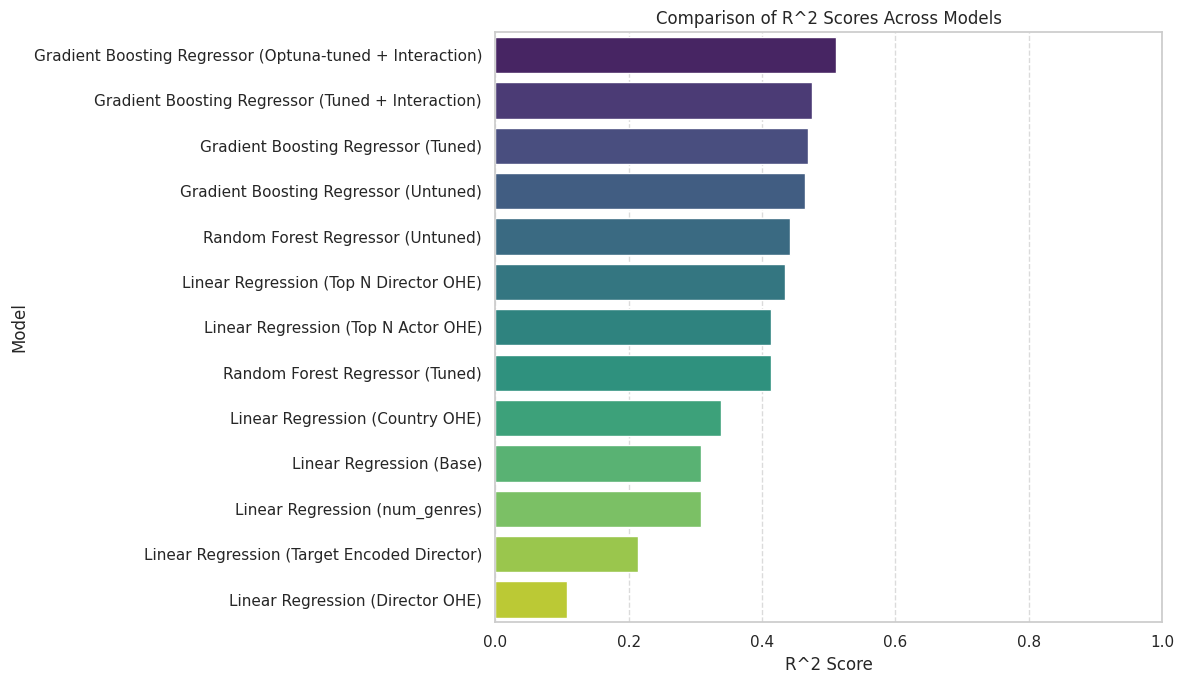

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by R^2 Score for better visualization
performance_df_sorted_r2 = performance_df.sort_values(by='R^2 Score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='R^2 Score', y='Model', data=performance_df_sorted_r2, palette='viridis')
plt.title('Comparison of R^2 Scores Across Models')
plt.xlabel('R^2 Score')
plt.ylabel('Model')
plt.xlim(0, 1) # R^2 scores typically range from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

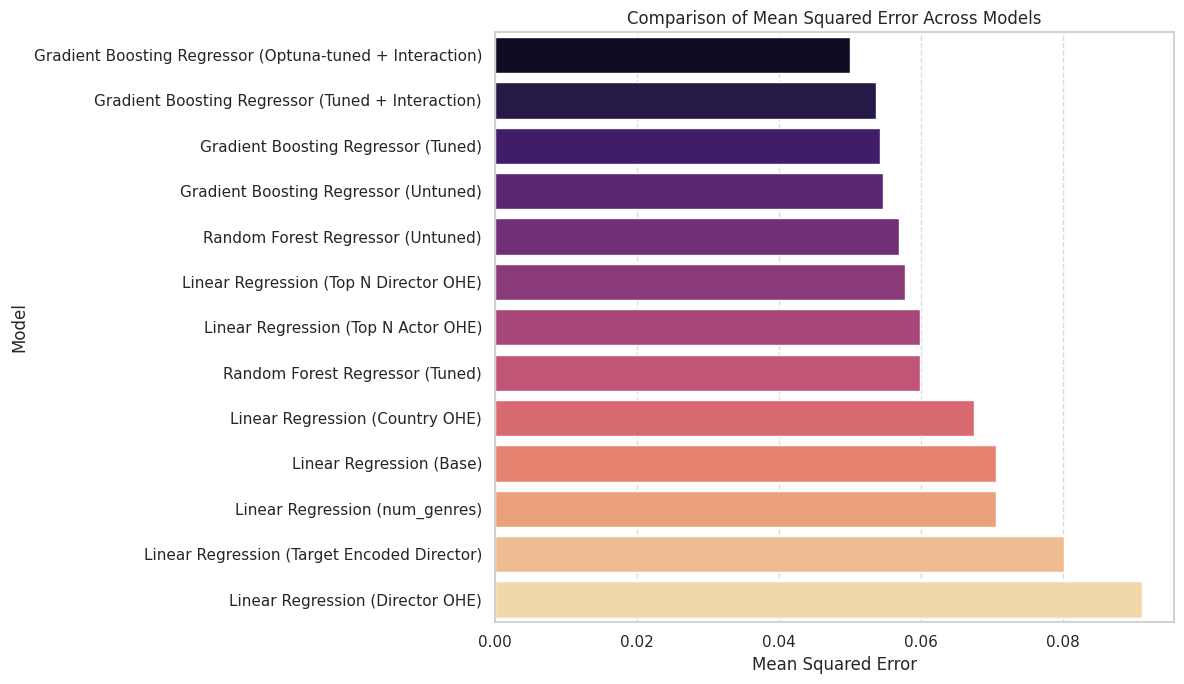

In [40]:
# Sort the DataFrame by Mean Squared Error (MSE) for better visualization (lower MSE is better)
performance_df_sorted_mse = performance_df.sort_values(by='Mean Squared Error', ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Mean Squared Error', y='Model', data=performance_df_sorted_mse, palette='magma')
plt.title('Comparison of Mean Squared Error Across Models')
plt.xlabel('Mean Squared Error')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

# Create a dictionary to store the R^2 and MSE scores for each model
model_performance = {
    'Model': [
        'Linear Regression (Base)',
        'Linear Regression (num_genres)',
        'Linear Regression (Country OHE)',
        'Linear Regression (Director OHE)',
        'Linear Regression (Top N Actor OHE)',
        'Linear Regression (Top N Director OHE)',
        'Linear Regression (Target Encoded Director)',
        'Random Forest Regressor (Untuned)',
        'Random Forest Regressor (Tuned)',
        'Gradient Boosting Regressor (Untuned)',
        'Gradient Boosting Regressor (Tuned)',
        'Gradient Boosting Regressor (Tuned + Interaction)',
        'Gradient Boosting Regressor (Optuna-tuned + Interaction)'
    ],
    'R^2 Score': [
        r2,
        r2_new,
        r2_encoded,
        r2_director,
        r2_actor,
        r2_top_director,
        r2_target_encoded_director,
        r2_rf,
        r2_rf_tuned,
        r2_gb,
        r2_gb_tuned,
        r2_gb_interaction,
        r2_gb_optuna_tuned
    ],
    'Mean Squared Error': [
        mse,
        mse_new,
        mse_encoded,
        mse_director,
        mse_actor,
        mse_top_director,
        mse_target_encoded_director,
        mse_rf,
        mse_rf_tuned,
        mse_gb,
        mse_gb_tuned,
        mse_gb_interaction,
        mse_gb_optuna_tuned
    ]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)

# Sort by R^2 Score in descending order
performance_df = performance_df.sort_values(by='R^2 Score', ascending=False).reset_index(drop=True)

display(performance_df)

,Model,R^2 Score,Mean Squared Error
0,Gradient Boosting Regressor (Optuna-tuned + In...,0.510860,0.049981
1,Gradient Boosting Regressor (Tuned + Interaction),0.474912,0.053654
2,Gradient Boosting Regressor (Tuned),0.468657,0.054293
3,Gradient Boosting Regressor (Untuned),0.464937,0.054673
4,Random Forest Regressor (Untuned),0.442362,0.056980
5,Linear Regression (Top N Director OHE),0.434855,0.057747
6,Linear Regression (Top N Actor OHE),0.414251,0.059852
7,Random Forest Regressor (Tuned),0.413949,0.059883
8,Linear Regression (Country OHE),0.339068,0.067535
9,Linear Regression (Base),0.309045,0.070603


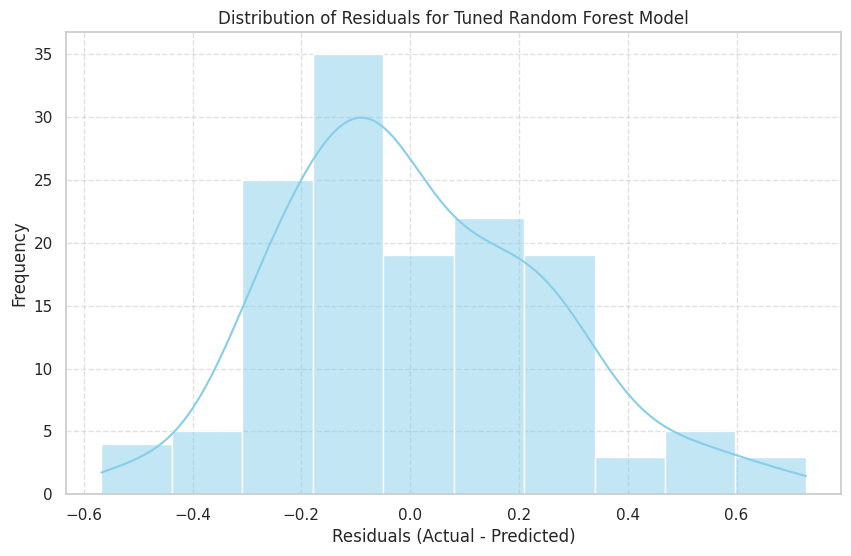

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the Tuned Random Forest model
residuals_rf = y_test_rf - y_pred_rf_tuned

plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True, color='skyblue')
plt.title('Distribution of Residuals for Tuned Random Forest Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

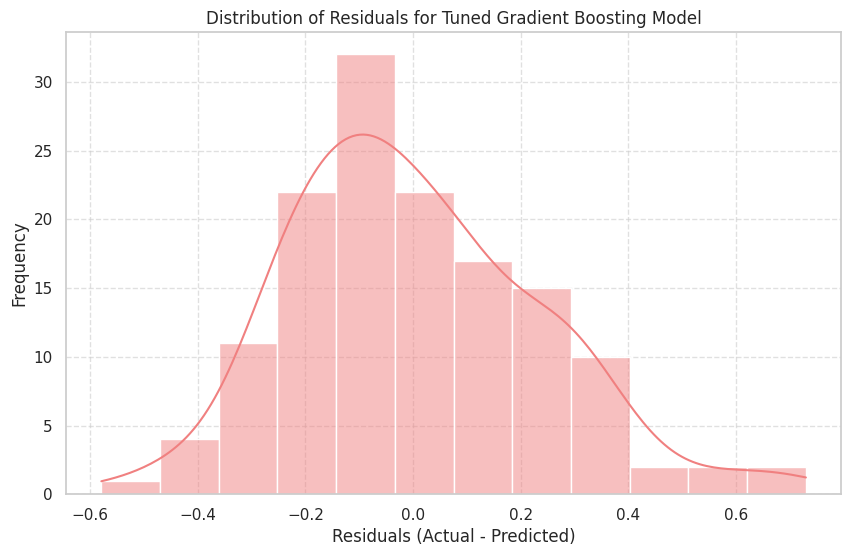

In [27]:
# Calculate residuals for the Tuned Gradient Boosting model
residuals_gb = y_test_gb - y_pred_gb_tuned

plt.figure(figsize=(10, 6))
sns.histplot(residuals_gb, kde=True, color='lightcoral')
plt.title('Distribution of Residuals for Tuned Gradient Boosting Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

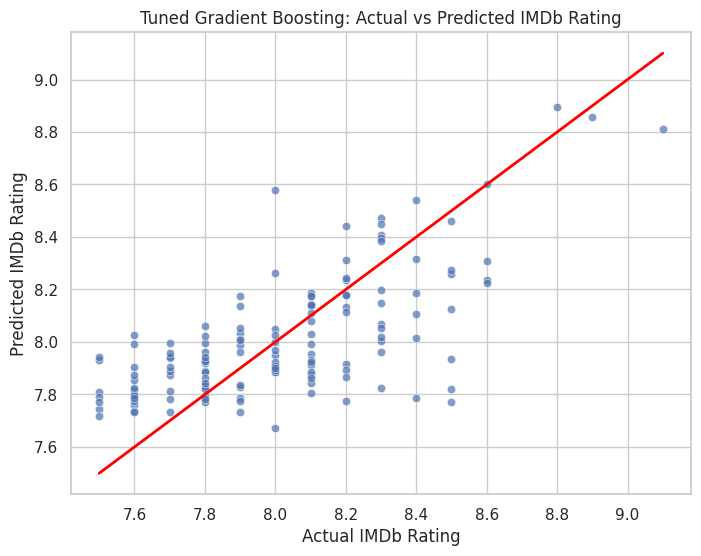

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_gb, y=y_pred_gb_tuned, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Tuned Gradient Boosting: Actual vs Predicted IMDb Rating")
plt.plot([y_test_gb.min(), y_test_gb.max()], [y_test_gb.min(), y_test_gb.max()], color='red', lw=2)  # reference line
plt.show()

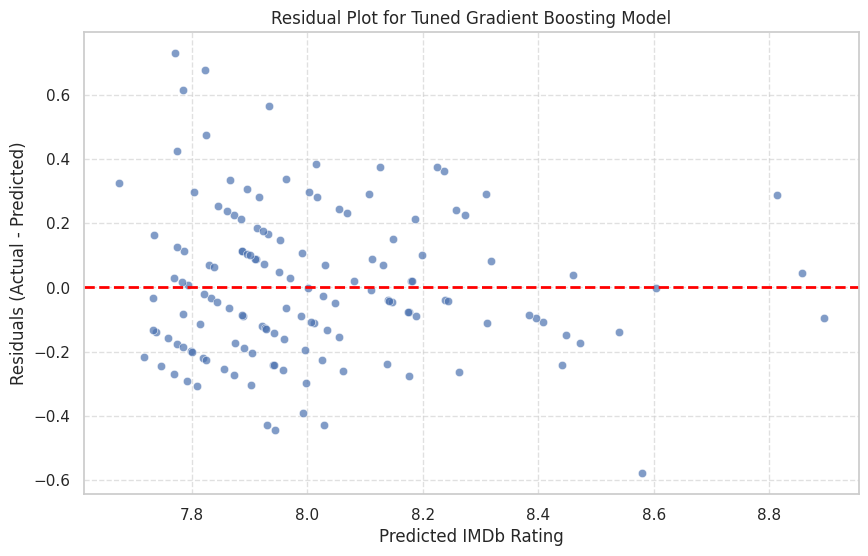

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a residual plot for the Tuned Gradient Boosting model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_gb_tuned, y=residuals_gb, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', lw=2) # Add a horizontal line at y=0
plt.title('Residual Plot for Tuned Gradient Boosting Model')
plt.xlabel('Predicted IMDb Rating')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

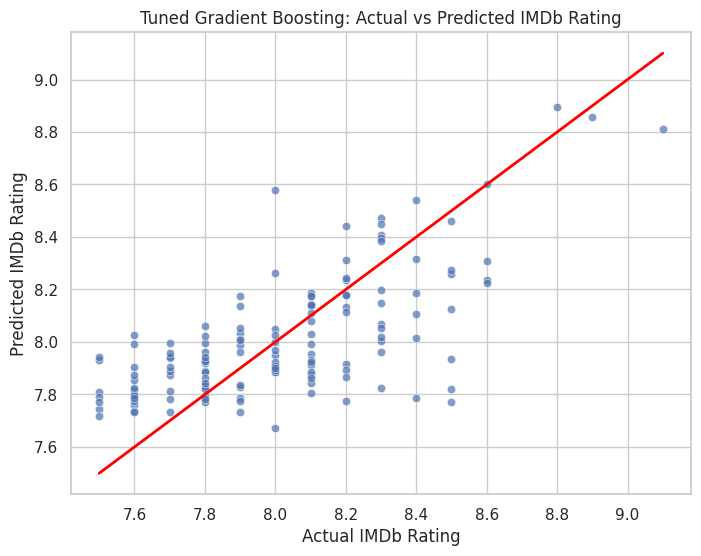

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_gb, y=y_pred_gb_tuned, alpha=0.7)
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.title("Tuned Gradient Boosting: Actual vs Predicted IMDb Rating")
plt.plot([y_test_gb.min(), y_test_gb.max()], [y_test_gb.min(), y_test_gb.max()], color='red', lw=2)  # reference line
plt.show()

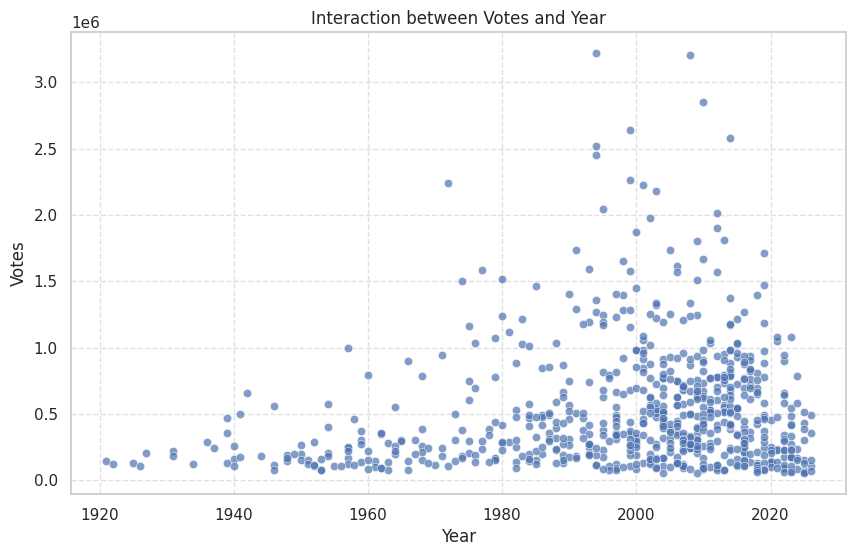

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='Votes', data=df, alpha=0.7)
plt.title('Interaction between Votes and Year')
plt.xlabel('Year')
plt.ylabel('Votes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Discussion and Future Work

This analysis started with a curiosity about the elements that contribute to a movie's high rating on IMDb. We explored the dataset by performing an initial cleaning, visualizing various aspects of the data, and then building a linear regression model to predict IMDb ratings based on the movie's year, the number of votes, and runtime.

The strengths of this approach are its simplicity and the clarity it provides in linking features to the target variable. However, there are many avenues for further improvement. Future work could include:

- More sophisticated feature engineering, such as handling multi-label genres or analyzing textual data (Director, Main Actor(s)).
- Exploring non-linear models or ensemble methods to capture complex relationships.
- Including additional external data to enrich the prediction model.

If you enjoyed this deep dive into movie data as much as a cinephile enjoys a midnight screening, please upvote the notebook. Your support helps foster further exploration into the art and science of data analysis.